# Evaluation of a Retrieval-Augmented Generation (RAG) system using "gpt-5.4-mini" and "muse-glimmer-30b" models on SQuAD V2 Dataset. For the module Principles of Machine Learning (7WCM2032) Coursework

**Student Name**: Hector S. Lazcano Quintero Marmol  
**Student ID**: 25054284

# Copyright and Licensing

##

This Jupyter notebook is provided by Hector S. Lazcano Quintero Marmol for educational purposes. You are free to use, share, and modify the contents of this notebook under the following conditions:

- **Attribution**: You must give appropriate credit, provide a link to the original source, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the author or the University of Hertfordshire endorses you or your use.

  **Suggested Attribution**:

  This notebook was originally created by Hector Samuel Lazcano Quintero Marmol for the Principles of Machine Learning Module (7WCM2032) using as a starting point of reference the `Unit4_LLMs-1.ipynb`, Principles of Machine Learning (7WCM2032), University of Hertfordshire, 2024. Providing the correct attributions.

For any questions or further information, please contact Hector S. Lazcano Quintero Marmol at [hectorslqm@gmail.com](mailto:hectorslqm@gmail.com) or [hl25acd@herts.ac.uk](mailto:hl25acd@herts.ac.uk)

## Course material — Manal Helal, University of Hertfordshire

© 2024 Manal Helal, University of Hertfordshire

This Jupyter notebook is provided by Manal Helal, a lecturer at the University of Hertfordshire, for educational purposes. You are free to use, share, and modify the contents of this notebook under the following conditions:

1. **Attribution**: You must give appropriate credit, provide a link to the original source, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the lecturer or the University of Hertfordshire endorses you or your use.

   **Suggested Attribution**:

   This notebook was originally created by Manal Helal, University of Hertfordshire for the Principles of Machine Learning Module (7WCM2032) 2024.

2. **No Warranty**: The content of this notebook is provided "as-is," without warranty of any kind. The lecturer and the University of Hertfordshire make no representations or warranties, either express or implied, as to the accuracy, reliability, or completeness of the information provided herein.

3. **Limited Liability**: In no event shall the lecturer or the University of Hertfordshire be liable for any damages arising from the use of, or inability to use, the contents of this notebook, including but not limited to damages for loss of data, loss of profits, or interruption of business, even if advised of the possibility of such damages.

4. **Environment and Compatibility**: This notebook has been developed and tested in a specific environment. The lecturer and the University of Hertfordshire cannot guarantee that the notebook will function as expected in different environments. Users are responsible for ensuring compatibility and for addressing any issues that may arise.

For any questions or further information, please contact Manal Helal at m.helal@herts.ac.uk

### Attribution and record of changes

Provided in satisfaction of condition 1 above.

**Original source**: `Unit4_LLMs-1.ipynb`, Principles of Machine Learning (7WCM2032), University of Hertfordshire, 2024.

**Adapted from the original source, with modifications:**

| Component              | Modification                                                                                                                                                                                               |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `EmbeddingModel`       | `embed_single` merged into a single overloaded `embed` accepting either a string or a list; type aliases added.                                                                                            |
| `SimpleVectorDatabase` | Metadata ids assigned automatically using an offset from the insertion point to prevent retrieved documents from being untraceable due to mismatched ids.                                                  |
| `SimpleRAGSystem`      | Prompt template rewritten to require short answers to reduce the consumption of tokens, and reduce the refusal phrases to one sentence.                                                                    |
| `RAGResponse`          | Extended to include LLMResults, this container carries the token usage and latency from the LLM call.                                                                                                      |
| `RAGEvaluator`         | The original substring support check was replaced with the official SQuAD v2 protocol: exact match and token-level F1, maximised over reference answers, with decline handling for unanswerable questions. |

**Written for this coursework (not derived from the original source):** the `LLM` provider registry with the `OpenAILLM` and `NVidiaLLM` implementations, `LLMResults`, the `Dataset` and `DatasetQuestion` wrappers over SQuAD v2, the `Exploratory Data Analysis` section, the `NoRAG` baseline, the `Experiment` and `ExperimentResult` harness, and the whole of Sections 7 and 8 — the analysis DataFrame, the `Plot` class and every summary table.

## Dataset — SQuAD v2

The Stanford Question Answering Dataset v2.0 is distributed under the **Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0)** licence.
Dataset card: https://huggingface.co/datasets/rajpurkar/squad_v2

## Retrieval model — all-MiniLM-L6-v2

Sentence embeddings are produced with `sentence-transformers/all-MiniLM-L6-v2`, released under the **Apache License 2.0**. The model maps text to a 384-dimensional dense vector space and is used here to embed both the corpus paragraphs and the questions.
Model card: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

## Models evaluated

Neither model is redistributed in this work; both were accessed over their providers' APIs and are subject to those providers' terms of use.

| Model                   | Accessed through                                   |
| ----------------------- | -------------------------------------------------- |
| `gpt-5.4-mini`          | OpenAI API                                         |
| `meta/muse-glimmer-30b` | NVIDIA API (`https://integrate.api.nvidia.com/v1`) |

## Software

| Library                 | Version | Licence                  |
| ----------------------- | ------- | ------------------------ |
| `sentence-transformers` | 6.0.0   | Apache 2.0               |
| `datasets`              | 5.0.1   | Apache 2.0               |
| `openai`                | 3.6.0   | Apache 2.0               |
| `numpy`                 | 2.5.2   | BSD-3-Clause             |
| `pandas`                | 3.0.5   | BSD-3-Clause             |
| `matplotlib`            | 3.11.1  | PSF (matplotlib licence) |
| `python-dotenv`         | 1.2.3   | BSD-3-Clause             |

---

# References

Helal, M. (2024) _Unit4_LLMs-1.ipynb_ [Jupyter notebook]. Principles of Machine Learning (7WCM2032). University of Hertfordshire.

HuggingFace Evaluate Authors (2020) `squad_v2.py`: SQuAD v2 evaluation metric. Apache License 2.0. Available at: https://github.com/huggingface/evaluate/blob/main/metrics/squad_v2/squad_v2.py (Accessed: 7 September 2026).

Rajpurkar, P. (2018) `_squad_v2_ [Dataset]`. Hugging Face. Available at: https://huggingface.co/datasets/rajpurkar/squad_v2 (Accessed: 7 September 2026).

Rajpurkar, P., Jia, R. and Liang, P. (2018) 'Know what you don't know: unanswerable questions for SQuAD', _Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 2: Short Papers)_. Melbourne, Australia: Association for Computational Linguistics, pp. 784–789. Available at: https://doi.org/10.18653/v1/P18-2124 (Accessed: 7 September 2026).

Reimers, N. and Gurevych, I. (2019) 'Sentence-BERT: sentence embeddings using Siamese BERT-networks', _Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing_. Hong Kong: Association for Computational Linguistics. Available at: https://arxiv.org/abs/1908.10084 (Accessed: 7 September 2026).

Sentence-Transformers (no date) _all-MiniLM-L6-v2_ [Machine learning model]. Hugging Face. Available at: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2 (Accessed: 7 September 2026).

Waskom, M. (no date) _Visualizing distributions of data_. seaborn documentation. Available at: https://seaborn.pydata.org/tutorial/distributions.html (Accessed: 7 September 2026).

## BibTeX entries

Provided for convenience only; the Harvard list above is the reference list.

```bibtex
@inproceedings{rajpurkar-etal-2018-know,
    title = "Know What You Don{'}t Know: Unanswerable Questions for {SQ}u{AD}",
    author = "Rajpurkar, Pranav  and
      Jia, Robin  and
      Liang, Percy",
    editor = "Gurevych, Iryna  and
      Miyao, Yusuke",
    booktitle = "Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 2: Short Papers)",
    month = jul,
    year = "2018",
    address = "Melbourne, Australia",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/P18-2124",
    doi = "10.18653/v1/P18-2124",
    pages = "784--789",
    eprint={1806.03822},
    archivePrefix={arXiv},
    primaryClass={cs.CL}
}
```

```bibtex
@inproceedings{reimers-2019-sentence-bert,
    title = "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks",
    author = "Reimers, Nils and Gurevych, Iryna",
    booktitle = "Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing",
    month = "11",
    year = "2019",
    publisher = "Association for Computational Linguistics",
    url = "https://arxiv.org/abs/1908.10084"
}
```

---

# Declaration of Use of Generative AI

Generative AI was used as a coding and analysis assistant during the preparation of this notebook:

- **Claude (Anthropic)** was used in Sections 7 and 8. It contributed to the implementation of the plots and tables.
- **GitHub Copilot** was used throughout for small in-editor corrections and completions while writing the code.

The following tools are declared for completeness, although they are not generative AI. **ruff**, a deterministic static linter and formatter, was used to check style and formatting across the project. **Pylance** was used in the editor for type checking and diagnostics. Both analyse code against fixed rules and type information; neither generates or suggests new logic.

All experimental design decisions, the choice of research questions, the execution of the experiment and the conclusions drawn in the written report are the author's own. Every figure and table reported here was regenerated from the raw experimental records in `results/` and checked against them.

---

# Dependencies

Run the following command for installing the necessary dependencies:

```sh
pip install "datasets==5.0.1" "matplotlib==3.11.1" "numpy==2.5.2" "openai==3.6.0" "pandas==3.0.5" "python-dotenv==1.2.3"  "sentence-transformers==6.0.0"
```

The notebook also requires a `.env` file containing the necessary API keys for OpenAI, NVIDIA or both.

```text
# .env file should contain the necessary API keys, for example:
# OPENAI_API_KEY=your_openai_api_key
# NVIDIA_API_KEY=your_nvidia_api_key
```


# Index

- **Section 1**: EMBEDDINGS AND VECTOR SEARCH
- **Section 2**: LLM Models with two providers + SQuAD Dataset
  - **Section 2.1**: SQuAD Dataset
  - **Section 2.2**: Exploratory data analysis
- **Section 3**: RETRIEVAL-AUGMENTED GENERATION (RAG)
- **Section 4**: Evaluation
- **Section 5**: Build Experiment
- **Section 6**: Run the experiment
  - **Section 6.1**: Load results for post-processing and analysis
- **Section 7**: Post-processing and analysis
  - **Section 7.1**: Build the analysis DataFrame
  - **Section 7.2**: Plotting functions for analysis
  - **Section 7.3**: Summary tables for analysis
- **Section 8**: Run the analysis and generate plots and tables
  - **Section 8.1**: Summary of every metric in the brief
  - **Section 8.2**: Cost by configuration
  - **Section 8.3**: Figures
  - **Section 8.4**: Where the grounded answers went wrong
  - **Section 8.5**: Concrete failures in the model's responses


## SECTION 1: EMBEDDINGS AND VECTOR SEARCH


In [2]:
import time
from dataclasses import dataclass, field
from typing import overload

import numpy as np

type Vector = np.ndarray  # forma (dim,)
type Matrix = np.ndarray  # forma (n, dim)


class EmbeddingModel:
    """Wrapper for generating text embeddings using sentence-transformers."""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        """Initialize embedding model.

        Args:
            model_name: Name of the sentence-transformers model
        """
        from sentence_transformers import SentenceTransformer

        self._model = SentenceTransformer(model_name)
        self._dimension = self._model.get_embedding_dimension()

    @overload
    def embed(self, texts: str) -> Vector: ...

    @overload
    def embed(self, texts: list[str]) -> Matrix: ...

    def embed(self, texts: str | list[str]) -> np.ndarray:
        """Generate embeddings for a text or list of texts.

        Args:
            texts: A text string or list of text strings to embed

        Returns:
            numpy array of shape (len(texts), dimension) if texts is a list, or (dimension,) if texts is a single string
        """
        if isinstance(texts, str):
            # Generate embedding for a single text.
            return self._model.encode([texts], normalize_embeddings=True)[0]

        return self._model.encode(texts, normalize_embeddings=True)


class SimpleVectorDatabase:
    """In-memory vector database for storing and retrieving embeddings."""

    def __init__(self, embedding_model: EmbeddingModel):
        self._embedding_model = embedding_model
        self._documents: list[str] = []
        self._metadata: list[dict] = []
        self._embeddings: np.ndarray | None = None

    def add_documents(
        self, documents: list[str], metadata: list[dict] | None = None
    ) -> None:
        """Add documents to the vector database.

        Args:
            documents: List of text documents
            metadata: Optional metadata for each document
        """
        if metadata is None:
            # Offset by the current index size to ensure unique ids.
            start = len(self._documents)
            metadata = [{"id": start + i} for i in range(len(documents))]

        # Generate embeddings for all documents at once
        embeddings = self._embedding_model.embed(documents)

        self._documents.extend(documents)
        self._metadata.extend(metadata)

        if self._embeddings is None:
            self._embeddings = embeddings
        else:
            self._embeddings = np.vstack([self._embeddings, embeddings])

    def search(self, query: str, top_k: int = 4) -> list[tuple[str, float, dict]]:
        """Search for the most similar documents to a query.

        Args:
            query: Search query text
            top_k: Number of results to return

        Returns:
            List of tuples (document_text, similarity_score, metadata)
        """
        query_vec = self._embedding_model.embed(query)

        # Compute cosine similarity
        similarities = np.dot(self._embeddings, query_vec)  # type: ignore

        # Get top_k indices
        top_indices = np.argsort(similarities)[-top_k:][::-1]

        results = []
        for idx in top_indices:
            results.append(
                (self._documents[idx], float(similarities[idx]), self._metadata[idx])
            )

        return results

## SECTION 2: LLM Models with two providers + SQuAD Dataset


In [3]:
import os
from typing import ClassVar

from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()


@dataclass
class LLMResults:
    """Container for the results returned by the LLM."""

    answer: str
    latency_s: float
    prompt_tokens: int
    completion_tokens: int


class LLM:
    """
    Creates a base class for Large Language Models (LLMs) with a registry for different providers.

    Raises:
        NotImplementedError: Raised when the generate method is not implemented in the subclass.
        ValueErrorption: Raised when an unsupported model provider is specified.

    Returns:
        An instance of the LLM subclass corresponding to the specified provider.
    """

    provider: ClassVar[str]
    _registry: ClassVar[dict[str, type["LLM"]]] = {}

    @property
    def model_name(self) -> str:
        """Return the name of the model being used."""
        return ""

    def generate(self, prompt: str) -> LLMResults:
        """Generates a response from the language model based on the given prompt.

        Args:
            prompt (str): The input prompt to generate a response for.

        Raises:
            NotImplementedError: Raised when the generate method is not implemented in the subclass.

        Returns:
            An instance of LLMResults containing the generated response and associated metadata.
        """
        raise NotImplementedError

    def __init_subclass__(cls, **kwargs):
        """
        Registers the subclass in the LLM registry based on its provider attribute.
        """
        super().__init_subclass__(**kwargs)
        if provider := getattr(cls, "provider", None):
            LLM._registry[provider.upper()] = cls

    @staticmethod
    def create(provider: str, model_name: str) -> "LLM":
        """
        Creates an instance of the LLM subclass corresponding to the specified provider.

        Args:
            provider (str): The name of the model provider (e.g., "OPENAI", "NVIDIA").
            model_name (str): The name of the model to be used.

        Raises:
            ValueError: Raised when an unsupported model provider is specified.

        Returns:
            An instance of the LLM subclass corresponding to the specified provider.
        """
        try:
            factory = LLM._registry[provider.upper()]
            return factory(model_name)  # type: ignore[call-arg]
        except KeyError:
            raise ValueError(f"Unsupported model provider: {provider}")


class OpenAILLM(LLM):
    """
    A subclass of LLM to interact specifically with OpenAI's language models.
    **IMPORTANT**:
        Make sure to set the OPENAI_API_KEY environment variable before using this class.
    Args:
        model_name (str): The name of the OpenAI model to be used.

    Returns:
        OpenAILLM: An instance of the OpenAILLM class initialized with the specified model.
    """

    # Define the provider for the OpenAILLM class
    provider: ClassVar[str] = "OPENAI"

    API_KEY = os.getenv("OPENAI_API_KEY")

    def __init__(self, model_name: str):
        self._client = OpenAI(api_key=self.API_KEY)
        self._model_name = model_name

    @property
    def model_name(self) -> str:
        """Return the name of the model being used."""
        return self._model_name

    def generate(self, prompt: str) -> LLMResults:
        start = time.perf_counter()
        response = self._client.responses.create(
            model=self._model_name,
            input=prompt,
            reasoning={"effort": "medium"},
        )
        latency = time.perf_counter() - start
        usage = getattr(response, "usage", None)
        return LLMResults(
            answer=response.output_text,
            latency_s=latency,
            prompt_tokens=usage.input_tokens if usage else 0,
            completion_tokens=usage.output_tokens if usage else 0,
        )


class NVidiaLLM(LLM):
    """
    A subclass of LLM to interact specifically with NVIDIA's language models.
    **IMPORTANT**:
        Make sure to set the NVIDIA_API_KEY environment variable before using this class.

    Args:
        model_name (str): The name of the NVIDIA model to be used.

    Returns:
        NVidiaLLM: An instance of the NVidiaLLM class initialized with the specified model.
    """

    # Define the provider for the NVidiaLLM class
    provider: ClassVar[str] = "NVIDIA"

    NVIDIA_BASE_URL = "https://integrate.api.nvidia.com/v1"
    API_KEY = os.getenv("NVIDIA_API_KEY")

    def __init__(self, model_name: str):
        self._client = OpenAI(base_url=self.NVIDIA_BASE_URL, api_key=self.API_KEY)
        self._model_name = model_name

    @property
    def model_name(self) -> str:
        """Return the name of the model being used."""
        return self._model_name

    def generate(self, prompt: str) -> LLMResults:
        start = time.perf_counter()
        response = self._client.chat.completions.create(
            model=self._model_name,
            messages=[{"role": "user", "content": prompt}],
            # Limiting the range of randomness to make the output reproducible
            temperature=0,
            top_p=0.95,
            max_tokens=8192,
            stream=False,
        )
        latency = time.perf_counter() - start
        usage = getattr(response, "usage", None)
        return LLMResults(
            answer=response.choices[0].message.content or "",
            latency_s=latency,
            prompt_tokens=usage.prompt_tokens if usage else 0,
            completion_tokens=usage.completion_tokens if usage else 0,
        )

### SECTION 2.1: SQuAD Dataset


In [4]:
import random

from datasets import load_dataset


@dataclass
class DatasetQuestion:
    """Container for a single question in the dataset."""

    id: str
    question: str
    # If empty, the question is unanswerable
    answers: list[str]
    # Index of the correct paragraph within the corpus
    context_id: int
    is_answerable: bool = field(init=False)

    # Assign is_answerable based on whether there are any answers. Right after initialization
    def __post_init__(self):
        self.is_answerable = len(self.answers) > 0


class Dataset:
    """Dataset wrapper for loading contexts and questions.
    - SQuAD v2 dataset by default. But can be configured to use other datasets as well.
        - This dataset is composed by two subsets: "train" and "validation". We are using the "validation" subset by default.
    - Seed for random number generation to ensure reproducibility. 42 by default.

    See the Copyright and Licensing section of the notebook for more information on the dataset's usage and restrictions.
    """

    def __init__(
        self,
        dataset: str = "rajpurkar/squad_v2",
        split: str = "validation",
        seed: int = 42,
    ):
        CONTEXT = "context"
        QUESTION = "question"
        ANSWERS = "answers"
        TEXT = "text"

        # Load the specified split of the dataset and initialize the random number generator.
        self._dataset_name = dataset
        self._split = split
        self._seed = seed
        self._dataset = load_dataset(dataset, split=split)
        self._random = random.Random(seed)
        # Corpus of unique contexts sorted in ascending order
        self._corpus = sorted(self._dataset.unique(CONTEXT))
        # Mapping from context to its index in the corpus
        self._context_to_id = {context: idx for idx, context in enumerate(self._corpus)}

        # Initialize the list of questions
        self._questions: list[DatasetQuestion] = []
        self._questions_by_id: dict[str, DatasetQuestion] = {}
        # Create a QAPair for each row in the dataset and store it
        for row in self._dataset:
            question = DatasetQuestion(
                id=row["id"],  # type: ignore
                question=row[QUESTION],  # type: ignore
                # Remove duplicated answers while preserving order
                answers=list(dict.fromkeys(row[ANSWERS][TEXT])),  # type: ignore
                # Store the corresponding id of the context in the corpus
                context_id=self._context_to_id[row[CONTEXT]],  # type: ignore
            )
            self._questions.append(question)
            self._questions_by_id[question.id] = question

    @property
    def dataset_name(self) -> str:
        """Return the name of the dataset being used."""
        return self._dataset_name

    @property
    def split(self) -> str:
        """Return the split of the dataset being used."""
        return self._split

    @property
    def seed(self) -> int:
        """Return the seed used for random number generation."""
        return self._seed

    @property
    def corpus(self) -> list[str]:
        """Return the list of unique contexts in the corpus."""
        return self._corpus

    def get_questions(
        self, n: int | None = None, only_answerable: bool | None = None
    ) -> list[DatasetQuestion]:
        """
        Return a list of questions based on the specified criteria.

        n: Number of questions to return. If None (or larger than the pool), return all matching questions in dataset order.
        only_answerable: If True, return only answerable questions. If False, only unanswerable ones. If None, no filtering.

        Returns:
            A list of Question objects. When n is smaller than the pool, a random
            sample drawn from the generator, so results are reproducible.
        """
        questions = self._questions
        if only_answerable is not None:
            questions = [q for q in questions if q.is_answerable == only_answerable]
        if n is None or n >= len(questions):
            return list(questions)
        return self._random.sample(questions, n)

    def _get_question_by_id(self, question_id: str) -> DatasetQuestion:
        question = self._questions_by_id.get(question_id)
        if question is None:
            raise ValueError(f"Question with ID {question_id} not found.")
        return question

    def context_for_question(self, question_id: str) -> str:
        """Return the context corresponding to the given question ID. This will be used to measure retrieval accuracy."""
        return self._corpus[self.get_context_id(question_id)]

    def get_context_id(self, question_id: str) -> int:
        return self._get_question_by_id(question_id).context_id

    def __len__(self) -> int:
        """Return the number of questions in the dataset."""
        return len(self._questions)

    def statistics(self) -> dict[str, int]:
        """Return basic statistics about the dataset."""
        answerable_questions = sum(1 for q in self._questions if q.is_answerable)
        return {
            "num_questions": len(self._questions),
            "num_contexts": len(self._corpus),
            "num_answerable_questions": answerable_questions,
            "num_unanswerable_questions": len(self._questions) - answerable_questions,
        }

/Users/hectorlazcano/Develop/computer-science/RAG-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### SECTION 2.2: Exploratory data analysis

Before building the pipeline, this section looks at what the split actually contains, because three decisions further down depend on it.

The first table shows the number of context and questions and divides by answerability.

The second table represents the number of words by text type: the paragraphs that go into the vector store, the questions, and the gold answers. The answer row only counts answerable questions, since the rest have no answer to measure.

In summary, the dataset has the following characteristics:

- The split is almost half answerable and half unanswerable. Making the evaluation of the model more balanced.
- The corpus repeats itself, with around ten questions per paragraph.
- Paragraphs are short enough to fit whole in the prompt, so they are embedded without requiring a chunking strategy. Leaving top-k as the only retrieval setting to tune.
- Answers are very short, two or three words on average.

> Contexts are deduplicated before indexing, so every question has exactly one gold paragraph and the retrieval hit rate becomes measurable.


questions                11873
unique contexts           1204
questions per context      9.9
answerable                5928
unanswerable              5945
unanswerable share       0.501
Name: rajpurkar/squad_v2 (validation), dtype: object

Word counts


,mean,median,min,max
context,126.6,113.0,25.0,629.0
question,10.0,10.0,3.0,31.0
answer,3.2,2.0,1.0,29.0


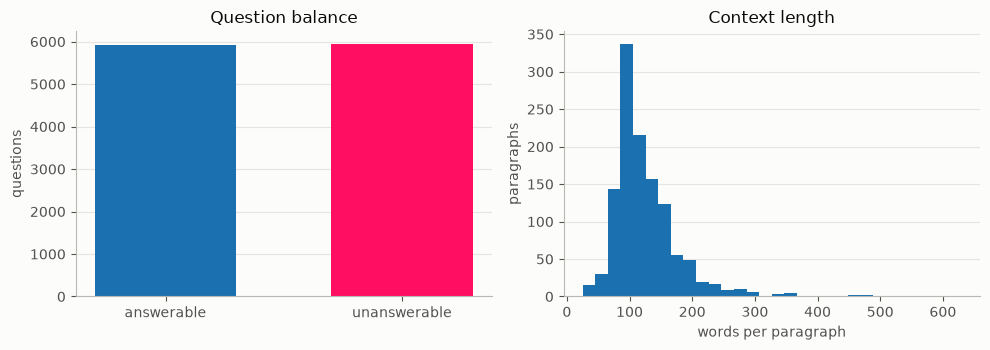

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# The full split, not a sample: the EDA has to describe the corpus the
# retriever indexes and the pool the experiment samples its questions from.
eda_dataset = Dataset()
eda_questions = eda_dataset.get_questions()


def dataset_overview(dataset: Dataset) -> pd.Series:
    """Retrieves a dataset overview. How many questions are answerable versus unanswerable."""
    stats = dataset.statistics()
    questions = stats["num_questions"]
    contexts = stats["num_contexts"]
    unanswerable = stats["num_unanswerable_questions"]
    return pd.Series(
        {
            "questions": questions,
            "unique contexts": contexts,
            "questions per context": round(questions / contexts, 1),
            "answerable": stats["num_answerable_questions"],
            "unanswerable": unanswerable,
            "unanswerable share": round(unanswerable / questions, 3),
        },
        # Object dtype keeps the counts as integers.
        dtype=object,
        name=f"{dataset.dataset_name} ({dataset.split})",
    )


def length_summary(dataset: Dataset, questions: list[DatasetQuestion]) -> pd.DataFrame:
    """Word counts for the three texts the pipeline handles.

    The answer row counts the first reference answer of every answerable
    question; unanswerable ones have none to measure.
    """
    lengths = {
        "context": [len(context.split()) for context in dataset.corpus],
        "question": [len(question.question.split()) for question in questions],
        "answer": [
            len(question.answers[0].split())
            for question in questions
            if question.is_answerable
        ],
    }
    summary = {
        name: pd.Series(values).agg(["mean", "median", "min", "max"])
        for name, values in lengths.items()
    }
    return pd.DataFrame(summary).T.round(1)


def plot_dataset(dataset: Dataset, figure_path: Path = Path("figures")) -> None:
    """The two properties that decide how the rest of the notebook is built:
    the answerable / unanswerable balance, and how long a paragraph is.
    """
    figure_path.mkdir(exist_ok=True)
    stats = dataset.statistics()
    # Same two series colours the Plot class uses later, so the figures match.
    colors = ("#1b71af", "#ff0e62")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

    axes[0].bar(
        ["answerable", "unanswerable"],
        [stats["num_answerable_questions"], stats["num_unanswerable_questions"]],
        color=colors,
        width=0.6,
    )
    axes[0].set_title("Question balance")
    axes[0].set_ylabel("questions")

    axes[1].hist(
        [len(context.split()) for context in dataset.corpus],
        bins=30,
        color=colors[0],
    )
    axes[1].set_title("Context length")
    axes[1].set_xlabel("words per paragraph")
    axes[1].set_ylabel("paragraphs")

    # The Plot class sets these globally, but it is defined further down and
    # the EDA runs first, so apply them here to keep the figures consistent.
    for ax in axes:
        ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    fig.savefig(figure_path / "dataset_eda.png", dpi=150)
    plt.show()


display(dataset_overview(eda_dataset))
print("Word counts")
display(length_summary(eda_dataset, eda_questions))
plot_dataset(eda_dataset)


## SECTION 3: RETRIEVAL-AUGMENTED GENERATION (RAG)


In [5]:
@dataclass
class RAGResponse:
    """Container for RAG response with sources."""

    answer: str
    sources: list[dict]
    context_used: list[str]
    confidence: float
    llm_results: LLMResults | None


# Updated the original two unanswerable phrases to a single unanswerable phrase.
UNANSWERABLE_PHRASE = "I don't have an answer"


class SimpleRAGSystem:
    """
    A complete RAG system that:
    1. Indexes documents
    2. Retrieves relevant context
    3. Generates grounded answers
    """

    def __init__(self, vector_db: SimpleVectorDatabase, llm_model: LLM):
        self._vector_db = vector_db
        self._llm_model = llm_model

    def _format_context(self, retrieved_docs: list[tuple[str, float, dict]]) -> str:
        """Format retrieved documents for inclusion in the prompt."""
        formatted = []
        for i, (doc, score, meta) in enumerate(retrieved_docs, 1):
            formatted.append(f"[{i}] {doc}")
        return "\n\n".join(formatted)

    def _create_prompt(
        self, question: str, context: list[tuple[str, float, dict]]
    ) -> str:
        """Create the complete prompt."""
        context_str = self._format_context(context)

        prompt = """Answer using ONLY the context below. I want you to answer in the shortest possible way. If the answer is not present, say exactly: "{unanswerable_phrase}"

Context:
{context}

Question: {question}

Answer:"""

        return prompt.format(
            context=context_str,
            question=question,
            unanswerable_phrase=UNANSWERABLE_PHRASE,
        )

    def answer(self, question: str, top_k: int = 4) -> RAGResponse:
        """Generate a RAG answer for a question."""
        answer, llm_results = None, None
        # Retrieve relevant documents
        retrieved = self._vector_db.search(question, top_k=top_k)

        # Create the prompt
        prompt = self._create_prompt(question, retrieved)

        # Generate answer using the LLM
        if self._llm_model is not None:
            llm_results = self._llm_model.generate(prompt)
            answer = llm_results.answer
        # If no LLM model is provided, the answer will remain None.

        # Extract sources for transparency
        sources = [
            {
                # Truncate the document text to 100 characters
                "text": doc[:100] + "..." if len(doc) > 100 else doc,
                "score": score,
                "metadata": meta,
            }
            for doc, score, meta in retrieved
        ]

        return RAGResponse(
            answer=answer or "",
            sources=sources,
            context_used=[doc for doc, _, _ in retrieved],
            confidence=retrieved[0][1] if retrieved else 0.0,
            llm_results=llm_results,
        )


class NoRAG:
    """
    This class provides an answer without using the RAG system.
    This is required for the plain test scenario where no RAG is used.
    """

    def __init__(self, llm_model: LLM):
        self._llm_model = llm_model

    def _create_prompt(
        self, question: str, context: list[tuple[str, float, dict]] | None = None
    ) -> str:
        """Create the complete prompt."""
        prompt = """I want you to answer in the shortest possible way. If you do not know the answer, say exactly: "{unanswerable_phrase}"

Question: {question}

Answer:"""

        return prompt.format(question=question, unanswerable_phrase=UNANSWERABLE_PHRASE)

    def answer(self, question: str) -> RAGResponse:
        """Get a plain answer for a question without additional context."""
        prompt = self._create_prompt(question=question)
        llm_results = self._llm_model.generate(prompt)
        return RAGResponse(
            answer=llm_results.answer,
            sources=[],
            context_used=[],
            confidence=0.0,
            llm_results=llm_results,
        )

## SECTION 4: Evaluation


In [6]:
import re
import string
from collections import Counter


def _normalize_texts(text: str) -> str:
    """Lowercase, strip punctuation and articles, and normalize whitespace.
    E.G. "The CAR runs fast." -> "car runs fast"
    The normalization follows the SQuAD v2 evaluation protocol for exact match and F1 score calculations. See the Copyright and Licensing section of the notebook for the source of this normalization function.
    """
    text = text.lower().strip()
    text = "".join(
        character for character in text if character not in string.punctuation
    )

    # Remove articles (a, an, the) from the text.
    text = re.sub(r"\b(a|an|the)\b", " ", text)

    return " ".join(text.split())


# Normalized should look like: i dont have answer
UNANSWERABLE_TOKEN = _normalize_texts(UNANSWERABLE_PHRASE)


def clean_model_answer(raw: str | None) -> str:
    """Clean the model's raw answer.

    Args:
        raw (str | None): The raw answer from the model.

    Returns:
        str: The cleaned answer, with leading/trailing whitespace removed. Returns an empty string if the input is None.
    """
    if raw is None:
        return ""
    return raw.strip()


class RAGEvaluator:
    """Evaluate a RAG system against test questions.

    Adapted from the module notebook's RAGEvaluator: the substring-support
    check was replaced with the official SQuAD v2 protocol (EM / token-F1,
    max over reference answers, decline handling for unanswerable questions).

    """

    @staticmethod
    def is_declined(answer: str) -> bool:
        """True if the model used the UNANSWERABLE_PHRASE"""
        return UNANSWERABLE_TOKEN in _normalize_texts(answer)

    @staticmethod
    def _em_single(prediction: str, reference: str) -> float:
        """Exact match between one prediction and one reference answer"""
        return float(_normalize_texts(prediction) == _normalize_texts(reference))

    @staticmethod
    def _f1_single(prediction: str, reference: str) -> float:
        """Token-overlap F1 between one prediction and one reference answer.

        This is the SQuAD token-level F1, not the classification F1: precision
        and recall are counted over the bag of whitespace tokens shared by the
        two normalized strings, so a partially correct span still scores.
        """
        # First we normalize the prediction and reference answers.
        prediction_tokens = _normalize_texts(prediction).split()
        reference_tokens = _normalize_texts(reference).split()
        if not prediction_tokens or not reference_tokens:
            return float(prediction_tokens == reference_tokens)
        # Compute the number of overlapping tokens between prediction and reference
        common = Counter(prediction_tokens) & Counter(reference_tokens)
        # Compute the overlap and calculate precision, recall, and F1 score
        overlap = sum(common.values())
        if overlap == 0:
            return 0.0
        precision = overlap / len(prediction_tokens)
        recall = overlap / len(reference_tokens)
        # Compute the F1 Score
        return 2 * precision * recall / (precision + recall)

    @classmethod
    def evaluate_answer(cls, prediction: str, reference_answers: list[str]) -> dict:
        """Evaluate a single answer against the reference answers.
        Returns:
            A dictionary with keys "em", "f1", and "declined". "em" and "f1" are float scores, "declined" is a boolean indicating if the model declined to answer.
        """
        prediction = clean_model_answer(prediction)
        declined = cls.is_declined(prediction)

        if not reference_answers:  # unanswerable question
            score = float(declined)
            return {"em": score, "f1": score, "declined": declined}

        if declined:  # declined an answerable question
            return {"em": 0.0, "f1": 0.0, "declined": True}

        em = max(cls._em_single(prediction, ref) for ref in reference_answers)
        f1 = max(cls._f1_single(prediction, ref) for ref in reference_answers)
        return {"em": em, "f1": f1, "declined": False}

    @classmethod
    def is_supported_by_sources(
        cls, prediction: str, used_contexts: list[str]
    ) -> bool | None:
        """Answer-supported-by-source rat.
        Returns:
            True if the normalized answer appears inside any context used, False if not. None when there is nothing to check (declined answers or plain runs with no RAG)
        """

        prediction = clean_model_answer(prediction)
        if not used_contexts or cls.is_declined(prediction):
            return None
        normalized_prediction = _normalize_texts(prediction)
        if not normalized_prediction:
            return None

        # Compare whole words, not raw characters. A plain substring test
        # matches inside longer words ("no" is found in "north"), which would
        # inflate this rate: about 11% of SQuAD v2 answers are 4 characters
        # or shorter, so the spurious matches are not a rare edge case.
        prediction_tokens = normalized_prediction.split()

        def _contains(context: str) -> bool:
            context_tokens = _normalize_texts(context).split()
            n = len(prediction_tokens)
            return any(
                context_tokens[i : i + n] == prediction_tokens
                for i in range(len(context_tokens) - n + 1)
            )

        return any(_contains(context) for context in used_contexts)

## SECTION 5: Build Experiment


In [7]:
import json
from dataclasses import asdict
from pathlib import Path


@dataclass
class ExperimentResult:
    """Container for a single experiment result."""

    llm_model: str
    config: str
    seed: int
    question_id: str
    is_answerable: bool
    answer: str
    em: float
    f1: float
    declined: bool
    retrieval_hit: bool | None
    supported_by_source: bool | None
    retrieved_ids: list[int]
    top_similarity: float
    latency_s: float
    prompt_tokens: int
    completion_tokens: int


class Experiment:
    """Package the experiment configuration and results in a single object."""

    def __init__(self):
        self._embedding_model = EmbeddingModel()
        self._records: list[ExperimentResult] = []

    def _read_processed_pairs(self, results_file: Path) -> set[tuple[str, str, str]]:
        """Return a list of tuples (llm_model, config, question_id) from the processed results"""
        done = set()
        if results_file.exists():
            with open(results_file) as f:
                for line in f:
                    record = json.loads(line)
                    done.add(
                        (record["llm_model"], record["config"], record["question_id"])
                    )
        return done

    @property
    def records(self) -> list[ExperimentResult]:
        """Return the list of experiment records."""
        return self._records

    def clear_records(self, results_file: Path, seed: int):
        """Clear records for this seed and remove its results file if it exists."""
        self._records = [r for r in self._records if r.seed != seed]
        if results_file.exists():
            results_file.unlink()

    def run_experiment(
        self,
        dataset: Dataset,
        llms: list[LLM],
        seed: int,
        n_questions: int,
        top_k_values: list[int | None],
        results_path: Path = Path("results"),
        replace_existing: bool = False,
    ):
        """Run the experiment with the given configuration and save results to a file.
        dataset: Dataset object containing the questions and contexts
        llms: List of LLM objects to be evaluated
        seed: Random seed for reproducibility
        n_questions: Number of questions to sample from the dataset for evaluation
        top_k_values: List of top_k values for retrieval. Use None to include the NoRAG baseline in the experiment.
        results_path: Path to the directory where results will be saved. Defaults to "results".
        replace_existing: If True, clear existing records for this seed and remove the results file if it exists.
        """
        results_path.mkdir(exist_ok=True)
        # Initialize the vector database, and add documents from the dataset's corpus. with the given seed
        vector_db = SimpleVectorDatabase(self._embedding_model)
        vector_db.add_documents(dataset.corpus)
        # Retrieve a random sample of questions from the dataset.
        questions = dataset.get_questions(n=n_questions)
        # Create the results file path and check for already completed evaluations to avoid redundant computations.
        results_file = results_path / f"results_seed{seed}.jsonl"

        # If replace_existing is True, clear existing records for this seed and remove the results file if it exists.
        # Otherwise, read already processed pairs from the results file to skip them during evaluation.
        if replace_existing:
            self.clear_records(results_file, seed)
            processed = set()
        else:
            processed = self._read_processed_pairs(results_file)

        print("=" * 60)
        print(f"Running experiment with seed {seed}, {len(questions)} questions.")
        print(f"Dataset: {dataset.dataset_name}, Split: {dataset.split}, Seed: {seed}")
        with open(results_file, "a") as f:
            for top_k in top_k_values:
                for llm in llms:
                    print(
                        f"RAG With Top-k retrieval: {top_k if top_k is not None else 'Plain Prompting (No RAG)'}"
                    )
                    print(f"LLM model: {llm.model_name}")

                    model_name = llm.model_name
                    # Initialize the system. If top_k is None, use NoRAG; otherwise, use SimpleRAGSystem with the specified top_k.
                    if top_k is not None:
                        config = f"rag_k-{top_k}"
                        # Initialize the RAG System with the current LLM model and vector database
                        system = SimpleRAGSystem(vector_db, llm_model=llm)
                    else:
                        config = "plain"
                        system = NoRAG(llm_model=llm)

                    for i, question in enumerate(questions, start=1):
                        # Check if the current configuration and question ID have already been evaluated to avoid redundant computations.
                        if (model_name, config, question.id) in processed:
                            continue

                        if isinstance(system, SimpleRAGSystem) and top_k is not None:
                            response = system.answer(question.question, top_k=top_k)
                            retrieved_ids = [
                                source["metadata"]["id"] for source in response.sources
                            ]

                            retrieval_hit = question.context_id in retrieved_ids
                        else:
                            response = system.answer(question.question)
                            retrieved_ids = [
                                source["metadata"]["id"] for source in response.sources
                            ]

                            retrieval_hit = None

                        answer = clean_model_answer(response.answer)
                        metrics = RAGEvaluator.evaluate_answer(answer, question.answers)

                        supported = RAGEvaluator.is_supported_by_sources(
                            response.answer, response.context_used
                        )
                        if response.llm_results:
                            latency_s = response.llm_results.latency_s
                            prompt_tokens = response.llm_results.prompt_tokens
                            completion_tokens = response.llm_results.completion_tokens
                        else:
                            latency_s = 0.0
                            prompt_tokens = 0
                            completion_tokens = 0

                        record = ExperimentResult(
                            llm_model=model_name,
                            config=config,
                            seed=seed,
                            question_id=question.id,
                            is_answerable=question.is_answerable,
                            answer=answer,
                            em=metrics["em"],
                            f1=metrics["f1"],
                            declined=metrics["declined"],
                            retrieval_hit=retrieval_hit,
                            supported_by_source=supported,
                            retrieved_ids=retrieved_ids,
                            top_similarity=response.confidence,  # raw cosine sim
                            latency_s=latency_s,
                            prompt_tokens=prompt_tokens,
                            completion_tokens=completion_tokens,
                        )
                        self._records.append(record)
                        f.write(json.dumps(asdict(record)) + "\n")
                        f.flush()  # persist immediately
                        # Print progress and metrics for the current question, including the exact match (em), F1 score (f1), retrieval hit status, latency, and a truncated version of the answer.
                        print(
                            f"  [{i:>3}/{len(questions)}] em={metrics['em']:.0f} "
                            f"f1={metrics['f1']:.2f} hit={retrieval_hit} latency={latency_s:>5.1f}s | {answer[:100]}."
                        )
                    print(f"{config}: Processed")

## SECTION 6: Run the experiment


## About the experiment

This experiment evaluates a Retrieval-Augmented Generation (RAG)
by comparing the generated answers from two LLM models. The models used for this experiment are "muse-glimmer-30b" and "gpt-5.4-mini".
This experiment run 3 different randomized set of 100 questions from SQuAD V2 Dataset using the validation dataset, comparing plain answer, no context given in other words No RAG, and RAG answers with the following configurations; Top-k of 1, 3 and 5.

# Notes

This experiment took about 99minutes to finished and used a paid LLM Service. For the analysis, the preloaded results will be used instead of running the experiment again.

> You can skip the following cell and go to section 6.1

If you want to use a different LLM with a different set of configurations you can modify the following cell.

Use the corresponding .env Variable depending on the providers that you are going to use.

```bash
# Environment variables for API keys
NVIDIA_API_KEY=your_nvidia_api_key_here
OPENAI_API_KEY=your_openai_api_key_here
```

> The .env file must be placed in the root directory of the project


In [12]:
# Initialize a LLM factory
llm = LLM()
## Create instances of the LLMs to be used in the experiment
muse_glimmer = LLM.create("NVIDIA", "meta/muse-glimmer-30b")
gpt_mini = LLM.create("OPENAI", "gpt-5.4-mini")
QUESTIONS_PER_SEED = 100
SEEDS = (42, 43, 44)
experiment = Experiment()
for seed in SEEDS:
    dataset = Dataset(dataset="rajpurkar/squad_v2", split="validation", seed=seed)
    experiment.run_experiment(
        dataset=dataset,
        llms=[gpt_mini, muse_glimmer],
        seed=seed,
        n_questions=QUESTIONS_PER_SEED,
        top_k_values=[None, 1, 5, 10],
        results_path=Path("results"),
        replace_existing=True,
    )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9051.76it/s]


Running experiment with seed 42, 100 questions.
Dataset: rajpurkar/squad_v2, Split: validation, Seed: 42
RAG With Top-k retrieval: Plain Prompting (No RAG)
LLM model: gpt-5.4-mini
  [  1/100] em=1 f1=1.00 hit=None latency=  7.4s | I don't have an answer.
  [  2/100] em=1 f1=1.00 hit=None latency=  1.7s | Lothar de Maizière.
  [  3/100] em=0 f1=0.00 hit=None latency= 10.3s | I don't have an answer.
  [  4/100] em=0 f1=0.00 hit=None latency=  6.0s | I don't have an answer.
  [  5/100] em=0 f1=0.00 hit=None latency=  7.3s | withdraw cash.
  [  6/100] em=0 f1=0.00 hit=None latency=  1.3s | Diffusion..
  [  7/100] em=0 f1=0.00 hit=None latency=  1.0s | Oxygen.
  [  8/100] em=0 f1=0.00 hit=None latency= 14.2s | I don't have an answer.
  [  9/100] em=1 f1=1.00 hit=None latency=  1.6s | Poet.
  [ 10/100] em=0 f1=0.00 hit=None latency=  1.9s | They emerge in synchronized, prime-number cycles to overwhelm predators and survive..
  [ 11/100] em=0 f1=0.00 hit=None latency=  1.3s | Noyon.
  [ 12/10

### Section 6.1: Load results for post-processing and analysis


For the next sections it is required to have the experiment results previuosly executed.
If you are using the generated files from the experiment then change `LOAD_FROM_FILE` variable to `True` and make sure the files are located in the same directory as this notebook under the `results` folder.


In [40]:
def load_results(results_dir: Path) -> list[ExperimentResult]:
    """Read every seed file into one flat list of records."""
    records = []
    for path in sorted(results_dir.glob("results_seed*.jsonl")):
        with open(path) as f:
            records.extend(
                ExperimentResult(**json.loads(line)) for line in f if line.strip()
            )
    return records


LOAD_FROM_FILE = True  # Set to True to load results from file instead of using the in-memory records from the experiment run above.
if LOAD_FROM_FILE and Path("results").exists():
    results = load_results(Path("results"))
    print(f"Loaded {len(results)} records from results directory.")
else:
    results = experiment.records
    print(f"Using {len(results)} records from the in-memory experiment run.")

Loaded 2400 records from results directory.


## SECTION 7: Post-processing and Analysis


### SECTION 7.1: Build the analysis DataFrame


For a correct analysis first we are going to convert the results into a pandas DataFrame. See `results_to_dataframe` function for more details.


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Answers scoring at or above this F1 count as "correct" wherever the analysis
# needs a yes/no split (the grounding cross-tab and the similarity histogram).
# EM is too strict for that job: a right answer carrying one extra word scores
# EM = 0 but F1 ~ 0.9, and would be filed as a failure.
CORRECT_F1_THRESHOLD = 0.5


def results_to_dataframe(results: list[ExperimentResult]) -> pd.DataFrame:
    """Turn the experiment records into the table the whole analysis reads from.

    Everything below this point becomes column arithmetic instead of nested
    loops, so each aggregation reads as the thing it computes.

    Three decisions are made here on purpose, once, instead of in every
    function downstream:

    - `retrieval_hit` and `supported_by_source` become pandas' nullable
      "boolean" dtype. In this experiment None means "not applicable" (the
      model declined, or it was a plain run with nothing retrieved) and NOT
      False. The nullable dtype keeps that difference, so `.mean()` skips
      those rows rather than counting them as zeros - which is exactly the
      mistake that would make a cautious model look good.
    - `config` becomes an *ordered* category, so every groupby, table and
      plot comes out as plain, rag_k-1, rag_k-5, rag_k-10 without anyone
      having to sort it again. Sorting the labels as text would put
      "rag_k-10" before "rag_k-5".
    - `correct`, `total_tokens` and `top_k` are derived once here.
    """
    frame = pd.DataFrame([asdict(r) for r in results])
    if frame.empty:
        return frame

    for column in ("retrieval_hit", "supported_by_source"):
        frame[column] = frame[column].astype("boolean")

    frame["correct"] = frame["f1"] >= CORRECT_F1_THRESHOLD
    frame["total_tokens"] = frame["prompt_tokens"] + frame["completion_tokens"]
    # "rag_k-10" -> 10. The plain baseline has no k, so it stays missing,
    # which is also what sorts it to the front below.
    frame["top_k"] = (
        frame["config"].str.extract(r"-(\d+)$", expand=False).astype("Int64")
    )

    ordered_configs = (
        frame[["config", "top_k"]]
        .drop_duplicates()
        .sort_values("top_k", na_position="first")["config"]
        .tolist()
    )
    frame["config"] = pd.Categorical(
        frame["config"], categories=ordered_configs, ordered=True
    )
    return frame


def config_order(frame: pd.DataFrame) -> list[str]:
    """Configurations present in the data, in reading order."""
    return list(frame["config"].cat.categories)


def model_order(frame: pd.DataFrame) -> list[str]:
    """Models present in the data, in a stable order."""
    return sorted(frame["llm_model"].unique())


def seed_order(frame: pd.DataFrame) -> list[int]:
    """This function simply retrieves the sorted seeds present in the data."""
    return sorted(int(seed) for seed in frame["seed"].unique())


def top_k_values(frame: pd.DataFrame) -> list[int]:
    """The retrieval depths that were actually run."""
    return sorted(int(k) for k in frame["top_k"].dropna().unique())


def _mean_per_seed(
    frame: pd.DataFrame,
    model: str,
    config: str,
    metric: str,
    subset: bool | None = None,
) -> list[float]:
    """One mean per seed, for one model under one configuration.

    Each seed is a separate sample of 100 questions, so the seed is the unit
    we average and take the spread over. Averaging all 300 answers together
    would understate how much the score moves between samples.

    subset: True for answerable questions only, False for unanswerable only,
    None for both. Seeds where the metric is missing everywhere drop out
    instead of contributing a zero.
    """
    rows = frame[(frame["llm_model"] == model) & (frame["config"] == config)]
    if subset is not None:
        rows = rows[rows["is_answerable"] == subset]
    per_seed = rows.groupby("seed", observed=True)[metric].mean().dropna()
    return [float(value) for value in per_seed]


def hydrate(frame: pd.DataFrame, dataset: Dataset) -> pd.DataFrame:
    """Join the question text, the gold answers and the passages back onto the
    records, so a failure can be quoted in the report instead of only counted.

    The experiment stores ids, not prose. `retrieved_ids` are indices into
    `dataset.corpus`, which is `sorted(unique(context))` - a stable order that
    does not depend on the seed - so every passage is recoverable offline from
    the ids alone. Nothing here calls an API or re-runs the experiment.

    Any Dataset instance will do: the corpus and the id -> question lookup are
    seed-independent, only the *sample* of questions drawn from it is not.

    The retrieved passages are stored as references into the same corpus list,
    not as copies, so the extra columns cost list overhead rather than one
    duplicate of the text per row.
    """
    corpus = dataset.corpus
    questions = {question.id: question for question in dataset.get_questions()}
    # Adding the columns for question text, gold answers, gold context, and retrieved context to the DataFrame.
    return frame.assign(
        question=frame["question_id"].map(lambda qid: questions[qid].question),  # type: ignore
        gold_answers=frame["question_id"].map(lambda qid: questions[qid].answers),  # type: ignore
        gold_context=frame["question_id"].map(
            lambda qid: corpus[questions[qid].context_id]  # type: ignore
        ),
        # A plain run retrieved nothing, so its list is empty rather than
        # missing: "the model was given no passages" is a fact, not a gap.
        retrieved_context=frame["retrieved_ids"].map(
            lambda ids: [corpus[doc_id] for doc_id in ids]  # type: ignore
        ),
    )


def _largest_ecdf_gap(
    correct: list[float], incorrect: list[float]
) -> tuple[float, float]:
    """Biggest vertical distance between the two ECDFs, and where it happens.

    This is the Kolmogorov-Smirnov statistic, read here for what it means
    operationally rather than as a test: at the cut-off that maximises it, the
    gap is (share of wrong answers stopped) - (share of right answers lost).
    It is the ceiling on any single threshold on this axis, so a small number
    rules the whole idea out rather than just the cut-offs that were tried.
    """
    if not correct or not incorrect:
        return 0.0, float("nan")

    correct_sorted = np.sort(correct)
    incorrect_sorted = np.sort(incorrect)
    # Every observed value is a candidate cut-off; the extremum of a step
    # function can only sit at a step.
    cutoffs = np.unique(np.concatenate([correct_sorted, incorrect_sorted]))
    lost = np.searchsorted(correct_sorted, cutoffs, side="right") / len(correct_sorted)
    stopped = np.searchsorted(incorrect_sorted, cutoffs, side="right") / len(
        incorrect_sorted
    )
    gaps = stopped - lost
    best = int(np.argmax(gaps))
    return float(gaps[best]), float(cutoffs[best])

### SECTION 7.2: Plotting functions for analysis


In [42]:
class Plot:
    """A class to encapsulate plotting functions for RAG experiment results."""

    # Define a set of colors for plotting different series in the analysis.
    # And keep consistent with the colors used in the notebook for visual clarity and comparison.
    SERIES_COLORS = ("#1b71af", "#ff0e62", "#0da70d", "#d1d408df", "#9467bd")

    def __init__(self, frame: pd.DataFrame, figure_path: Path = Path("figures")):
        self._frame = frame
        self._figure_path = figure_path

        # Update matplotlib's rcParams to customize the appearance of plots, including grid lines, colors, and other visual elements for better readability and aesthetics.
        plt.rcParams.update(
            {
                "axes.grid": True,
                "axes.grid.axis": "y",
                "grid.color": "#e5e4e0",
                "grid.linewidth": 0.8,
                "axes.axisbelow": True,
                "axes.spines.top": False,
                "axes.spines.right": False,
                "axes.edgecolor": "#b8b7b2",
                "axes.labelcolor": "#52514e",
                "text.color": "#0b0b0b",
                "xtick.color": "#52514e",
                "ytick.color": "#52514e",
                "figure.facecolor": "#fcfcfb",
                "axes.facecolor": "#fcfcfb",
            }
        )

    def plot_metric_by_config(
        self,
        frame: pd.DataFrame,
        metric: str = "f1",
        subset: bool | None = None,
        filename: str | None = None,
    ) -> None:
        """Grouped bars: one group per configuration, one bar per model.

        Error bars are the standard deviation across seeds, so they show how much
        the score moves when you resample the questions.
        """
        self._figure_path.mkdir(exist_ok=True)
        configs = config_order(frame)
        models = model_order(frame)

        subset_label = {
            None: "",
            True: " - answerable only",
            False: " - unanswerable only",
        }[subset]

        x = np.arange(len(configs))
        width = 0.8 / len(models)

        fig, ax = plt.subplots(figsize=(8, 4.5))
        top = 0.0
        for i, model in enumerate(models):
            means, stds = [], []
            for config in configs:
                per_seed = _mean_per_seed(frame, model, config, metric, subset)
                means.append(float(np.mean(per_seed)) if per_seed else 0.0)
                stds.append(float(np.std(per_seed)) if per_seed else 0.0)

            # 2px gap between adjacent bars so the fills never touch
            offset = (i - (len(models) - 1) / 2) * width
            bars = ax.bar(
                x + offset,
                means,
                width * 0.92,
                yerr=stds,
                capsize=3,
                label=model,
                color=self.SERIES_COLORS[i % len(self.SERIES_COLORS)],
                error_kw={"ecolor": "#52514e", "elinewidth": 1},
            )
            # Direct labels: identity is never carried by colour alone. Sit them
            # above the error bar, not the bar, so the two never overlap.
            for bar, mean, std in zip(bars, means, stds):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    mean + std + 0.02,
                    f"{mean:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="#52514e",
                )
                top = max(top, mean + std)

        n_seeds = len(seed_order(frame))
        ax.set_xticks(x, configs)
        ax.set_ylabel(f"mean {metric.upper()}")
        # Leave room for the labels; never clip an error bar that runs past 1.0
        ax.set_ylim(0, max(1.05, top + 0.12))
        ax.set_title(
            f"{metric.upper()} by configuration{subset_label}\n"
            f"mean ± std across {n_seeds} seed(s)",
            fontsize=11,
            loc="left",
        )
        ax.legend(frameon=False, fontsize=9)
        fig.tight_layout()

        name = filename or f"{metric}{subset_label.replace(' ', '_')}_by_config.png"
        fig.savefig(self._figure_path / name, dpi=150)
        plt.show()

    def plot_retrieval_hit_rate(self, frame: pd.DataFrame) -> None:
        """Line: share of questions whose own context made it into the top-k,
        split by whether the question has an answer at all.

        Retrieval runs before the LLM and uses the same embeddings for both
        models, so this is a property of the retriever alone - the models are
        not separated because they retrieved identical documents. Rows are
        de-duplicated by (seed, top_k, question) so a question is not counted
        once per model.

        Split because only the answerable line is a ceiling. Where an answer
        exists, a miss makes a correct answer impossible, so that line bounds
        everything downstream. An unanswerable question has nothing to find,
        so its hit-rate bounds nothing - it is shown because the gap is a
        finding of its own: SQuAD v2 writes unanswerable questions to look
        plausible against a paragraph, which makes them harder to retrieve.
        """
        self._figure_path.mkdir(exist_ok=True)
        rag = frame[frame["config"] != "plain"].dropna(subset=["retrieval_hit"])
        if rag.empty:
            print("No retrieval records to plot.")
            return

        per_question = rag.drop_duplicates(subset=["seed", "top_k", "question_id"])

        fig, ax = plt.subplots(figsize=(7, 4.5))
        # The two lines run close together at k=1, so their labels are pushed
        # to opposite sides of the marker instead of both sitting above it.
        series = [
            (
                True,
                "answerable (this line is the ceiling)",
                self.SERIES_COLORS[0],
                0.035,
                "bottom",
            ),
            (False, "unanswerable", self.SERIES_COLORS[1], -0.035, "top"),
        ]
        for answerable, label, color, offset, align in series:
            rows = per_question[per_question["is_answerable"] == answerable]
            # Mean within each seed first, then across seeds: the seed is the
            # sampling unit, so a seed with fewer questions must not weigh less.
            by_k = (
                rows.groupby(["top_k", "seed"], observed=True)["retrieval_hit"]
                .mean()
                .groupby("top_k", observed=True)
                .mean()
            )
            ks = [int(k) for k in by_k.index]
            rates = [float(rate) for rate in by_k]
            ax.plot(
                ks,
                rates,
                marker="o",
                linewidth=2,
                markersize=8,
                color=color,
                label=label,
            )
            for k, rate in zip(ks, rates):
                ax.text(
                    k,
                    rate + offset,
                    f"{rate:.3f}",
                    ha="center",
                    va=align,
                    fontsize=9,
                    color="#52514e",
                )

        ax.set_xlabel("top_k")
        ax.set_ylabel("retrieval hit-rate")
        ax.set_ylim(0, 1.12)
        ax.set_xticks(sorted(int(k) for k in per_question["top_k"].unique()))
        ax.set_title("Retrieval hit-rate vs top_k", fontsize=11, loc="left")
        ax.legend(frameon=False, fontsize=9, loc="lower right")
        fig.tight_layout()
        fig.savefig(self._figure_path / "retrieval_hit_rate.png", dpi=150)
        plt.show()

    def plot_similarity_distribution(self, frame: pd.DataFrame) -> None:
        """Grid of top-1 similarity histograms: one row per model, one column
        per RAG configuration.

        Motivates (or rules out) a similarity threshold as a second tuning axis:
        if wrong answers cluster at low similarity, declining below a cut-off
        would help without ever calling the LLM.

        Split rather than pooled, for two unrelated reasons. `plain` has no
        retriever, so its top_similarity is a 0.0 filler and not a measurement.
        And top-1 similarity is identical across k by construction - only the
        answer changes - so pooling the configs would repeat every question
        three times at the same x, inflating n with correlated rows and letting
        a single question land in both the correct and the incorrect histogram.
        """
        self._figure_path.mkdir(exist_ok=True)
        rag = frame[frame["config"] != "plain"]
        if rag.empty:
            print("No RAG answers to plot.")
            return

        models = model_order(rag)
        configs = [config for config in config_order(rag) if config != "plain"]

        # Bins come from every panel's data at once. Per-panel bins would give
        # each cell its own x range, so a bar in the same place would mean a
        # different similarity in each cell - which is the one thing a grid has
        # to make safe to compare.
        low, high = rag["top_similarity"].min(), rag["top_similarity"].max()
        pad = max((high - low) * 0.05, 0.01)
        bins = np.linspace(low - pad, high + pad, 21).tolist()

        fig, axes = plt.subplots(
            len(models),
            len(configs),
            figsize=(4.2 * len(configs), 3.4 * len(models)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for row, model in enumerate(models):
            for col, config in enumerate(configs):
                ax = axes[row][col]
                cell = rag[(rag["llm_model"] == model) & (rag["config"] == config)]
                correct = cell.loc[cell["correct"], "top_similarity"].tolist()
                incorrect = cell.loc[~cell["correct"], "top_similarity"].tolist()

                ax.hist(
                    [correct, incorrect],
                    bins=bins,
                    density=True,
                    rwidth=0.85,
                    color=[self.SERIES_COLORS[0], self.SERIES_COLORS[1]],
                )

                # Density normalises each group away from its own size, so the
                # counts have to be written down somewhere: a tall bar built
                # from four answers must not read like one built from four
                # hundred.
                ax.text(
                    0.97,
                    0.94,
                    f"F1 >= {CORRECT_F1_THRESHOLD}: {len(correct)}\n"
                    f"F1 <  {CORRECT_F1_THRESHOLD}: {len(incorrect)}",
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=8,
                    color="#52514e",
                )

                # Label the edges only: an inner cell inherits both its
                # column's config and its row's model from the panels around it.
                if row == 0:
                    ax.set_title(config, fontsize=10)
                if row == len(models) - 1:
                    ax.set_xlabel("top-1 cosine similarity")
                if col == 0:
                    ax.set_ylabel(model, fontsize=9)

        # Proxy handles rather than the bar containers: a cell where one group
        # is empty returns an empty container, and indexing into it would raise.
        legend_handles = [
            Patch(color=self.SERIES_COLORS[0]),
            Patch(color=self.SERIES_COLORS[1]),
        ]
        fig.legend(
            legend_handles,
            [f"F1 >= {CORRECT_F1_THRESHOLD}", f"F1 < {CORRECT_F1_THRESHOLD}"],
            frameon=False,
            fontsize=9,
            loc="lower center",
            ncol=2,
        )
        fig.suptitle(
            "Retrieval similarity: correct vs incorrect answers",
            fontsize=11,
            x=0.01,
            ha="left",
        )
        fig.supylabel("density (each group normalised separately)", fontsize=9)
        # Reserve the bottom strip for the shared legend
        fig.tight_layout(rect=(0.0, 0.05, 1.0, 1.0))
        fig.savefig(self._figure_path / "similarity_distribution.png", dpi=150)
        plt.show()

    def plot_similarity_ecdf(self, frame: pd.DataFrame) -> None:
        """ECDF of top-1 similarity, correct vs incorrect, on the same grid.

        The histogram shows the shape; this one answers the actual question.
        A rule of the form "decline below this similarity" is read straight
        off the y axis: at any cut-off, the pink curve is the share of wrong
        answers the rule would stop and the blue curve the share of right ones
        it would throw away. The rule is only worth having where pink runs
        clearly above blue - curves that travel together mean the threshold
        cannot separate the two groups at any value.

        An ECDF rather than a second histogram because it takes no bin width,
        so nothing in the picture is an artefact of a binning choice, and two
        monotone curves are easier to compare than two bar fields.
        Source: https://seaborn.pydata.org/tutorial/distributions.html
        """
        self._figure_path.mkdir(exist_ok=True)
        rag = frame[frame["config"] != "plain"]
        if rag.empty:
            print("No RAG answers to plot.")
            return

        models = model_order(rag)
        # `config_order` reads the column's categories, which survive a row
        # filter, so "plain" is still listed here even though no row has it.
        configs = [config for config in config_order(rag) if config != "plain"]

        fig, axes = plt.subplots(
            len(models),
            len(configs),
            figsize=(4.2 * len(configs), 3.4 * len(models)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for row, model in enumerate(models):
            for col, config in enumerate(configs):
                ax = axes[row][col]
                cell = rag[(rag["llm_model"] == model) & (rag["config"] == config)]
                correct = cell.loc[cell["correct"], "top_similarity"].tolist()
                incorrect = cell.loc[~cell["correct"], "top_similarity"].tolist()

                for values, color in (
                    (correct, self.SERIES_COLORS[0]),
                    (incorrect, self.SERIES_COLORS[1]),
                ):
                    if values:
                        ax.ecdf(values, color=color, linewidth=2)

                # The largest vertical gap between the curves is the best any
                # threshold on this axis can do. Naming it turns "the lines
                # look close" into a number the report can quote.
                gap, at = _largest_ecdf_gap(correct, incorrect)
                ax.text(
                    0.97,
                    0.06,
                    f"best gap {gap:.2f} @ {at:.2f}",
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=8,
                    color="#52514e",
                )

                if row == 0:
                    ax.set_title(config, fontsize=10)
                if row == len(models) - 1:
                    ax.set_xlabel("top-1 cosine similarity")
                if col == 0:
                    ax.set_ylabel(model, fontsize=9)

        legend_handles = [
            Patch(color=self.SERIES_COLORS[0]),
            Patch(color=self.SERIES_COLORS[1]),
        ]
        fig.legend(
            legend_handles,
            [
                f"F1 >= {CORRECT_F1_THRESHOLD} (would be lost)",
                f"F1 < {CORRECT_F1_THRESHOLD} (would be stopped)",
            ],
            frameon=False,
            fontsize=9,
            loc="lower center",
            ncol=2,
        )
        fig.suptitle(
            "Would a similarity threshold work? Share of each group at or below x",
            fontsize=11,
            x=0.01,
            ha="left",
        )
        fig.supylabel("cumulative share of the group", fontsize=9)
        fig.tight_layout(rect=(0.0, 0.05, 1.0, 1.0))
        fig.savefig(self._figure_path / "similarity_ecdf.png", dpi=150)
        plt.show()

    def plot_token_cost(self, frame: pd.DataFrame) -> None:
        """Stacked prompt + completion tokens per question, one panel per model.

        Stacked rather than two charts because the two parts move in opposite
        directions: retrieval buys a bigger prompt and pays for it with a
        shorter completion, and only the stack shows both the trade and the
        total it nets out to.

        Averaged per seed first, then across seeds, like every other figure
        here - the seed is the sampling unit, so the error bar on the total
        is the spread between question samples, not between questions.
        """
        self._figure_path.mkdir(exist_ok=True)
        configs = config_order(frame)
        models = model_order(frame)

        fig, axes = plt.subplots(
            1,
            len(models),
            figsize=(5.2 * len(models), 4.5),
            sharey=True,
            squeeze=False,
        )

        for col, model in enumerate(models):
            ax = axes[0][col]
            prompt, completion, totals, spread = [], [], [], []
            for config in configs:
                per_seed_prompt = _mean_per_seed(frame, model, config, "prompt_tokens")
                per_seed_completion = _mean_per_seed(
                    frame, model, config, "completion_tokens"
                )
                per_seed_total = _mean_per_seed(frame, model, config, "total_tokens")
                prompt.append(
                    float(np.mean(per_seed_prompt)) if per_seed_prompt else 0.0
                )
                completion.append(
                    float(np.mean(per_seed_completion)) if per_seed_completion else 0.0
                )
                totals.append(float(np.mean(per_seed_total)) if per_seed_total else 0.0)
                spread.append(float(np.std(per_seed_total)) if per_seed_total else 0.0)

            x = np.arange(len(configs))
            # edgecolor in the surface colour reads as a gap between the two
            # segments rather than as a border drawn around them.
            ax.bar(
                x,
                prompt,
                0.62,
                color=self.SERIES_COLORS[0],
                edgecolor="#fcfcfb",
                linewidth=1.5,
            )
            ax.bar(
                x,
                completion,
                0.62,
                bottom=prompt,
                color=self.SERIES_COLORS[2],
                edgecolor="#fcfcfb",
                linewidth=1.5,
                yerr=spread,
                capsize=3,
                error_kw={"ecolor": "#52514e", "elinewidth": 1},
            )

            # One label per bar - the total, which is the number the report
            # quotes. The split is readable off the segments and the axis.
            for xi, total, std in zip(x, totals, spread):
                ax.text(
                    xi,
                    total + std + max(totals) * 0.03,
                    f"{total:,.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="#52514e",
                )

            ax.set_xticks(x, configs)
            ax.set_title(model, fontsize=10, loc="left")
            if col == 0:
                ax.set_ylabel("mean tokens per question")

        top = max(
            float(np.mean(_mean_per_seed(frame, model, config, "total_tokens") or [0]))
            for model in models
            for config in configs
        )
        for ax in axes[0]:
            ax.set_ylim(0, top * 1.18)

        legend_handles = [
            Patch(color=self.SERIES_COLORS[0]),
            Patch(color=self.SERIES_COLORS[2]),
        ]
        fig.legend(
            legend_handles,
            ["prompt tokens", "completion tokens"],
            frameon=False,
            fontsize=9,
            loc="lower center",
            ncol=2,
        )
        n_seeds = len(seed_order(frame))
        fig.suptitle(
            "Token cost per question by configuration\n"
            f"stacked mean, error bar is std of the total across {n_seeds} seed(s)",
            fontsize=11,
            x=0.01,
            ha="left",
        )
        fig.tight_layout(rect=(0.0, 0.06, 1.0, 1.0))
        fig.savefig(self._figure_path / "token_cost.png", dpi=150)
        plt.show()

### SECTION 7.3: Summary tables for analysis


In [43]:
# What each quadrant of the grounding cross-tab means, so the table can be
# read without going back to the docstring.
GROUNDING_MEANING = {
    (True, True): "grounded and right",
    (True, False): "copied the wrong passage",
    (False, True): "right but reworded (metric blind spot)",
    (False, False): "invented (hallucination)",
}


def summary_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Every metric named in the brief, one row per model and configuration.

    Returned as a DataFrame rather than printed, so Jupyter renders it as a
    real table and the numbers can go straight into the report.

    decline_P / decline_R treat "the question is unanswerable" as the positive
    class: precision is how often a decline was justified, recall is how many
    of the unanswerable questions the model actually declined.

    `hit` and `in_ctx` average nullable columns, so their denominators are
    only the rows where the metric applies - declines and plain runs are
    missing by design, not zero.
    """
    flagged = frame.assign(
        decline_tp=frame["declined"] & ~frame["is_answerable"],
        decline_fp=frame["declined"] & frame["is_answerable"],
        decline_fn=~frame["declined"] & ~frame["is_answerable"],
    )

    table = flagged.groupby(["llm_model", "config"], observed=True).agg(
        EM=("em", "mean"),
        F1=("f1", "mean"),
        hit=("retrieval_hit", "mean"),
        in_ctx=("supported_by_source", "mean"),
        _tp=("decline_tp", "sum"),
        _fp=("decline_fp", "sum"),
        _fn=("decline_fn", "sum"),
        lat_s=("latency_s", "mean"),
        tokens=("total_tokens", "mean"),
    )

    # 0/0 gives NaN, which is the honest answer when a model never declined
    # (no precision to report) or every question was answerable (no recall).
    table["decline_P"] = table["_tp"] / (table["_tp"] + table["_fp"])
    table["decline_R"] = table["_tp"] / (table["_tp"] + table["_fn"])

    columns = ["EM", "F1", "hit", "in_ctx", "decline_P", "decline_R", "lat_s", "tokens"]
    return table[columns].astype(float).round(3)


def grounding_breakdown(frame: pd.DataFrame) -> pd.DataFrame:
    """Cross-tab of "supported by the context" against "answered correctly".

    `supported_by_source` on its own says whether the answer text appears in
    the retrieved documents - that is copying, not correctness. Crossed with
    F1 it separates the two failure modes, which have different fixes:

      supported + wrong     -> the retrieved passage was misread or was a distractor
      not supported + wrong -> the model ignored the context and invented an answer

    Only RAG answers that were actually given are counted. `scored` and
    `declined` are repeated on every row on purpose: `share` is out of the
    answers a model chose to give, so the shares are NOT comparable across
    models until you can see how many each one declined. A model that answers
    twice and copies well both times shows 100% here.
    """
    attempted = frame[frame["config"] != "plain"]
    scored = attempted.dropna(subset=["supported_by_source"])
    if scored.empty:
        return pd.DataFrame()

    # Safe after dropna, and it turns the nullable boolean into a plain one
    # so the quadrant lookup below matches on real True / False.
    scored = scored.assign(supported=scored["supported_by_source"].astype(bool))

    counts = scored.groupby(["llm_model", "supported", "correct"], observed=True).size()
    # Give every model all four quadrants, including the ones with no cases:
    # a zero in "invented (hallucination)" is a result worth showing.
    quadrants = pd.MultiIndex.from_product(
        [sorted(scored["llm_model"].unique()), [True, False], [True, False]],
        names=["llm_model", "supported", "correct"],
    )
    table = counts.reindex(quadrants, fill_value=0).rename("n").reset_index()

    n_scored = scored.groupby("llm_model", observed=True).size()
    n_attempted = attempted.groupby("llm_model", observed=True).size()
    table["scored"] = table["llm_model"].map(n_scored)
    table["declined"] = table["llm_model"].map(n_attempted - n_scored)
    table["share"] = (table["n"] / table["scored"]).round(3)
    table["failure_mode"] = [
        GROUNDING_MEANING[(supported, correct)]
        for supported, correct in zip(table["supported"], table["correct"])
    ]

    return table.set_index(["llm_model", "supported", "correct"])[
        ["n", "share", "scored", "declined", "failure_mode"]
    ]


HYDRATED_COLUMNS = ("question", "gold_answers", "gold_context", "retrieved_context")


def _require_hydrated(frame: pd.DataFrame) -> None:
    """Fail loudly rather than return a table of ids nobody can read."""
    missing = [column for column in HYDRATED_COLUMNS if column not in frame.columns]
    if missing:
        raise KeyError(
            f"call hydrate(frame, Dataset()) first - missing columns: {missing}"
        )


def _trim(text: str, width: int) -> str:
    """Whitespace-normalised text, cut to `width` characters.

    Line breaks inside a passage are collapsed before the cut: a single
    multi-line answer otherwise stretches its whole row and pushes the
    question it is supposed to explain off the side of the table.
    """
    text = " ".join(str(text).split())
    return text if len(text) <= width else text[: width - 1] + "…"


def _snippet(passages: list[str], width: int = 240) -> str:
    """First retrieved passage, trimmed to something quotable.

    The trim is for the table only - the untruncated passages stay in
    `retrieved_context`, so a quote for the report is always available as
    `frame.loc[index, "retrieved_context"][0]`.
    """
    return _trim(passages[0], width) if passages else ""


def find_failure_examples(
    frame: pd.DataFrame, n: int = 5, snippet_width: int = 240
) -> pd.DataFrame:
    """Hallucination candidates for the report: answers invented for
    questions that have no answer (the system did not decline).

    The gold answer is empty here by construction - the question has none -
    so what makes these rows explainable is the passage the model was looking
    at while it invented something. That is why the frame has to be hydrated.
    """
    _require_hydrated(frame)
    failures = frame[~frame["is_answerable"] & ~frame["declined"]].copy()
    failures["top_context"] = failures["retrieved_context"].map(
        lambda passages: _snippet(passages, snippet_width)
    )
    # A plain run retrieved nothing, so its row can be reported but not
    # diagnosed. Sort those last so `head` does not spend every slot on rows
    # whose top_context is blank.
    failures = failures.sort_values(
        "top_context", key=lambda column: column.eq(""), kind="stable"
    )
    columns = [
        "llm_model",
        "config",
        "question",
        "answer",
        "top_similarity",
        "top_context",
    ]
    return failures[columns].head(n)


def find_wrong_answer_examples(
    frame: pd.DataFrame,
    n: int = 5,
    snippet_width: int = 600,
    answer_width: int = 300,
) -> pd.DataFrame:
    """Answerable questions the model answered anyway, and got wrong.

    The complement of `find_failure_examples`, and the one that carries the
    gold answer: here a right answer exists, so the row can be diagnosed
    instead of merely reported. `retrieval_hit` splits the two causes that
    need different fixes - False means the retriever never surfaced the right
    passage, True means the model had it and still misread it.

    Sorted so the retrieval_hit=True rows come first: those are the ones that
    indict the model rather than the index, and they are the harder finding.

    The question is never trimmed - it is what the row is about, and a cut
    question cannot be diagnosed. `answer` and `top_context` are trimmed to
    `answer_width` and `snippet_width`, both wide enough to quote straight
    into the report; the untouched text stays in the frame this was built
    from, as `answer` and `retrieved_context`.
    """
    _require_hydrated(frame)
    wrong = frame[
        frame["is_answerable"] & ~frame["declined"] & ~frame["correct"]
    ].copy()
    # Collapse the line breaks but keep every word: the question is the one
    # column that has to survive intact.
    wrong["question"] = wrong["question"].map(lambda text: " ".join(str(text).split()))
    wrong["answer"] = wrong["answer"].map(lambda text: _trim(text, answer_width))
    wrong["top_context"] = wrong["retrieved_context"].map(
        lambda passages: _snippet(passages, snippet_width)
    )
    wrong = wrong.sort_values("retrieval_hit", ascending=False, na_position="last")
    columns = [
        "llm_model",
        "config",
        "question",
        "gold_answers",
        "answer",
        "f1",
        "retrieval_hit",
        "top_similarity",
        "top_context",
    ]
    return wrong[columns].head(n)


def cost_table(frame: pd.DataFrame) -> pd.DataFrame:
    """What each configuration costs, and what that spend buys.

    `vs_plain` is the total-token multiplier against the no-RAG baseline for
    the same model, so each model is compared to its own baseline rather than
    to the other model's. `f1_per_1k` is the efficiency column: quality per
    thousand tokens, which is the only place cost and accuracy are read
    together - a configuration can win on F1 and still lose here.
    """
    grouped = frame.groupby(["llm_model", "config"], observed=True)
    table = grouped.agg(
        prompt=("prompt_tokens", "mean"),
        completion=("completion_tokens", "mean"),
        total=("total_tokens", "mean"),
        lat_s=("latency_s", "mean"),
        F1=("f1", "mean"),
    )

    baseline = table.xs("plain", level="config")["total"]
    table["vs_plain"] = table["total"].div(baseline, level="llm_model")
    # Quality per thousand tokens: the trade-off the report has to argue.
    table["f1_per_1k"] = table["F1"] / table["total"] * 1000

    columns = ["prompt", "completion", "total", "vs_plain", "lat_s", "F1", "f1_per_1k"]
    return table[columns].round(
        {
            "prompt": 0,
            "completion": 0,
            "total": 0,
            "vs_plain": 2,
            "lat_s": 2,
            "F1": 3,
            "f1_per_1k": 3,
        }
    )

## SECTION 8: Run the analysis and generate plots and tables


In [44]:
results_frame = results_to_dataframe(results)
print(
    f"{len(results_frame)} records | models: {model_order(results_frame)} "
    f"| configs: {config_order(results_frame)} | seeds: {seed_order(results_frame)}"
)

# Join the question text, gold answers and passages back onto the records.
# Any Dataset works here: the corpus and the id lookup are seed-independent,
# so this recovers the prose offline from the stored ids - no API calls.
results_frame = hydrate(results_frame, Dataset())
print(f"hydrated columns: {[c for c in HYDRATED_COLUMNS]}")

# pandas truncates object columns at 50 characters by default, which cuts
# the questions and answers in the example tables below mid-sentence. The
# passages are trimmed deliberately by `_snippet`, so let the display show
# whatever a column actually holds.
pd.set_option("display.max_colwidth", None)

2400 records | models: ['gpt-5.4-mini', 'meta/muse-glimmer-30b'] | configs: ['plain', 'rag_k-1', 'rag_k-5', 'rag_k-10'] | seeds: [42, 43, 44]
hydrated columns: ['question', 'gold_answers', 'gold_context', 'retrieved_context']


### SECTION 8.1: Summary of every metric in the brief

#### Evaluation Metrics

- **EM**: Exact Match. The fraction of answers that exactly match the reference answers.
- **F1**: F1 score. The harmonic mean of precision and recall for the model's answers.

#### Retrieval and Context Metrics

The following columns evaluate the performance of the retriever. Making them identical for both models.

- **hit**: Retrieval Hit rate. The fraction of questions whose own source paragraph was among the `k` passages from the retriever.
- **in_ctx**: In Context. Measures how many of the questions were supported by the retrieved contexts.

#### Decline Metrics

- **decline_P**: Precision. How often a decline was justified,
- **decline_R**: Recall. How many of the unanswerable questions the model actually declined.

#### Latency and Token Metrics

- **lat_s**: Latency in seconds. How long the model took to respond.
- **tokens**: Number of tokens processed by the model.


In [45]:
summary_table(results_frame)

EM     F1    hit  in_ctx  decline_P  \
llm_model             config                                             
gpt-5.4-mini          plain     0.257  0.318    NaN     NaN      0.688   
                      rag_k-1   0.507  0.564  0.567   0.778      0.707   
                      rag_k-5   0.510  0.592  0.847   0.814      0.928   
                      rag_k-10  0.487  0.570  0.913   0.817      0.932   
meta/muse-glimmer-30b plain     0.427  0.475    NaN     NaN      0.654   
                      rag_k-1   0.687  0.729  0.567   0.860      0.720   
                      rag_k-5   0.753  0.819  0.847   0.868      0.878   
                      rag_k-10  0.763  0.828  0.913   0.902      0.898   

                                decline_R  lat_s    tokens  
llm_model             config                                
gpt-5.4-mini          plain         0.277  4.297   601.660  
                      rag_k-1       0.591  1.303   303.297  
                      rag_k-5       0.403  1.350   995.753  
                      rag_k-10      0.346  1.379  1827.283  
meta/muse-glimmer-30b plain         0.642  4.728   914.200  
                      rag_k-1       0.937  1.785   699.097  
                      rag_k-5       0.906  2.347  1462.810  
                      rag_k-10      0.887  2.483  2270.237

### SECTION 8.2: Cost by configuration

- **prompt**: Consumed tokens during the prompt
- **completion**: Consumed tokens during the completion
- **total**: Total consumed tokens (prompt + completion)
- **vs_plain**: Comparison of tokens against the plain model
- **lat_s**: Latency in seconds. Time taken to receive the response
- **F1**: F1 score of the model's responses
- **f1_per_1k**: F1 score normalized per 1,000 tokens


In [46]:
cost_table(results_frame)

prompt  completion   total  vs_plain  lat_s  \
llm_model             config                                                  
gpt-5.4-mini          plain       51.0       550.0   602.0      1.00   4.30   
                      rag_k-1    221.0        82.0   303.0      0.50   1.30   
                      rag_k-5    889.0       107.0   996.0      1.66   1.35   
                      rag_k-10  1722.0       105.0  1827.0      3.04   1.38   
meta/muse-glimmer-30b plain      101.0       813.0   914.0      1.00   4.73   
                      rag_k-1    271.0       428.0   699.0      0.76   1.78   
                      rag_k-5    939.0       524.0  1463.0      1.60   2.35   
                      rag_k-10  1772.0       499.0  2270.0      2.48   2.48   

                                   F1  f1_per_1k  
llm_model             config                      
gpt-5.4-mini          plain     0.318      0.529  
                      rag_k-1   0.564      1.861  
                      rag_k-5   0.592      0.594  
                      rag_k-10  0.570      0.312  
meta/muse-glimmer-30b plain     0.475      0.519  
                      rag_k-1   0.729      1.042  
                      rag_k-5   0.819      0.560  
                      rag_k-10  0.828      0.365

### SECTION 8.3: Figures


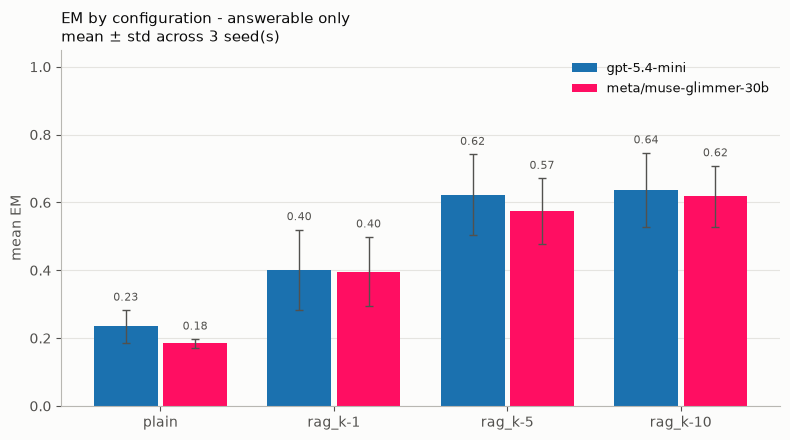

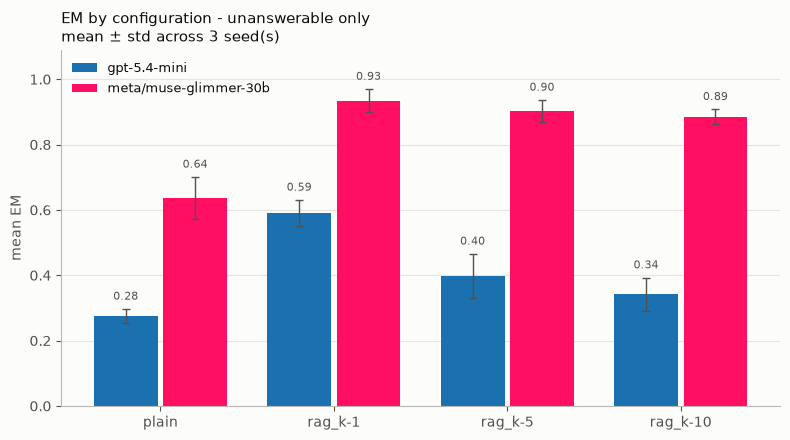

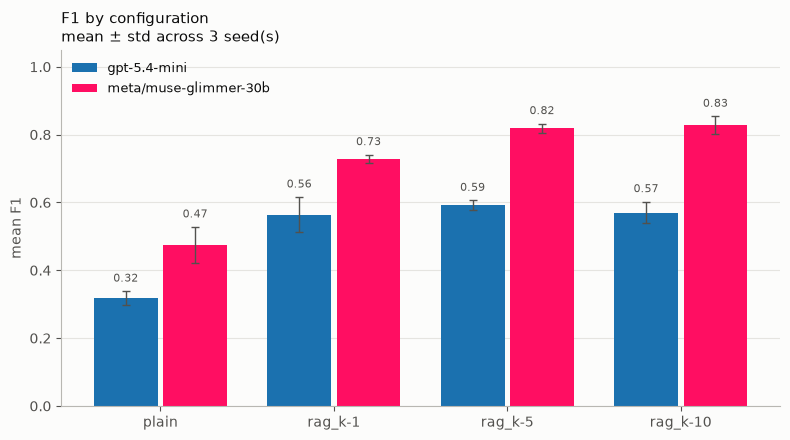

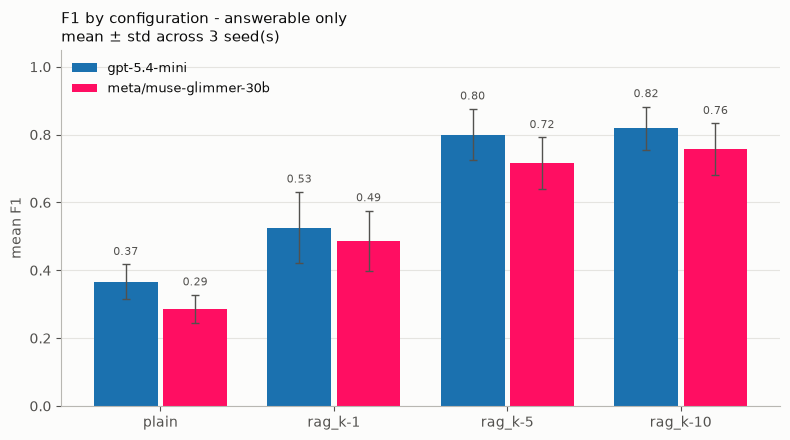

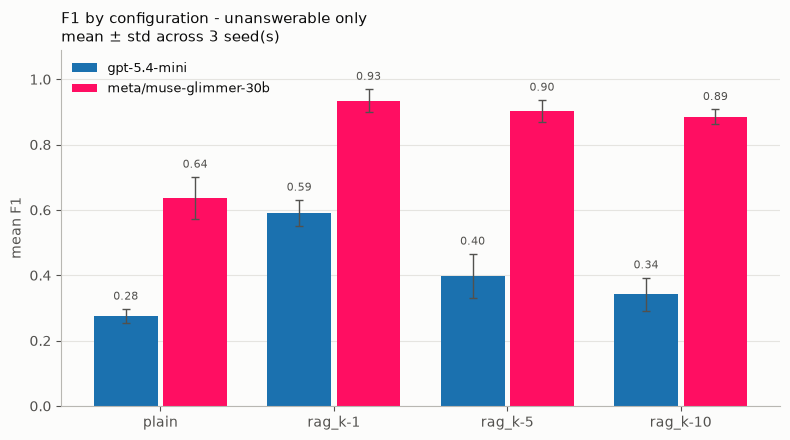

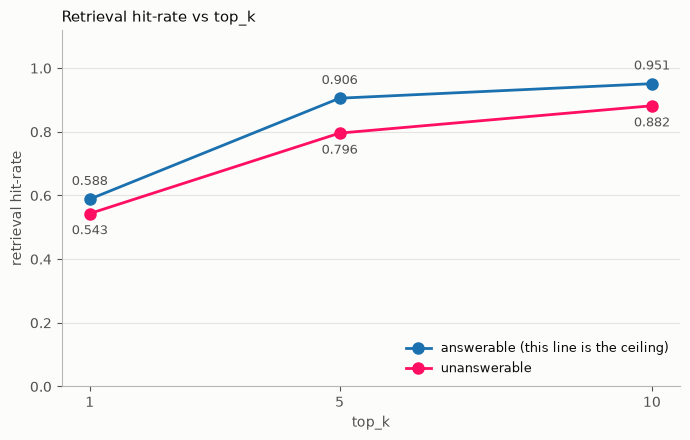

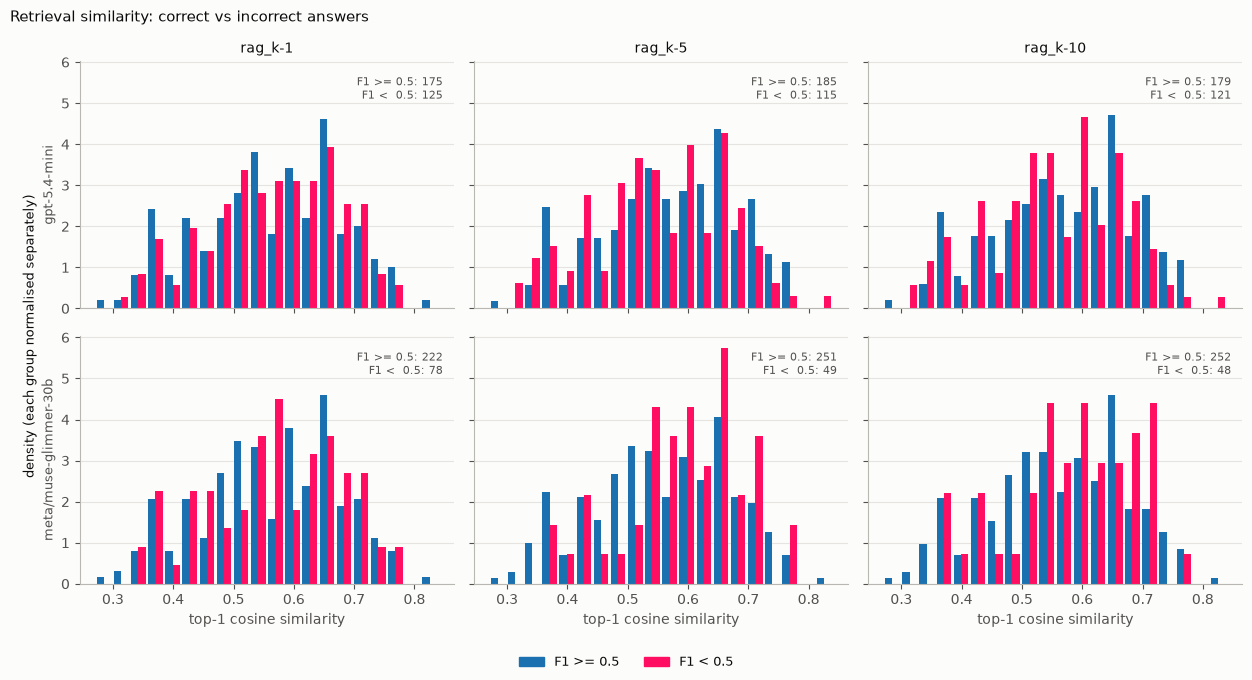

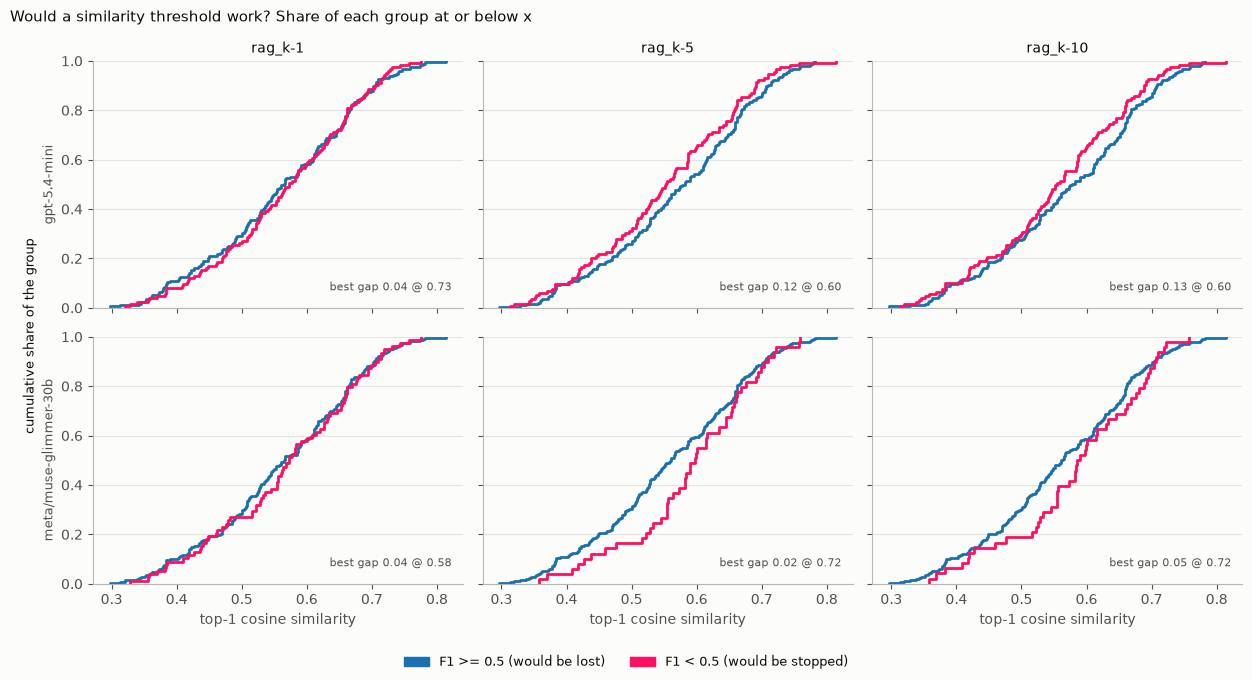

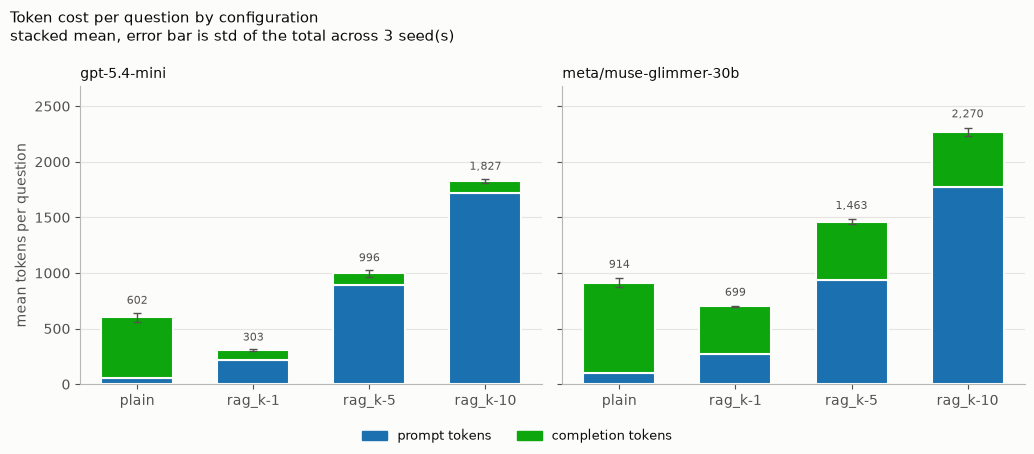

In [47]:
plot = Plot(results_frame)

# Exact match for all questions - Answerable
plot.plot_metric_by_config(results_frame, "em", subset=True)
# Exact match for all questions - Answerable
plot.plot_metric_by_config(results_frame, "em", subset=False)

# F1 for all questions - Answerable and unanswerable
plot.plot_metric_by_config(results_frame, "f1")
# F1 for answerable questions only
plot.plot_metric_by_config(results_frame, "f1", subset=True)
# F1 for unanswerable questions only
plot.plot_metric_by_config(results_frame, "f1", subset=False)
# Retrieval hit-rate: share of questions whose own context made it into the top-k
plot.plot_retrieval_hit_rate(results_frame)

plot.plot_similarity_distribution(results_frame)
plot.plot_similarity_ecdf(results_frame)
plot.plot_token_cost(results_frame)

### SECTION 8.4: Where the grounded answers went wrong

**Supported** is true when the answer appears in the retrieved passages, and **correct** is true when the answer is actually right.
**n** represents the number of scored questions that fit that category, while **share** is `n / scored`: the fraction of the answers.
**Declined** are the number of declined answers by the model.

As we can see **meta/muse-glimmer-30b** declined 528 of its 900 RAG attempts against 261 for
**gpt-5.4-mini**.


In [48]:
grounding_breakdown(results_frame)

n  share  scored  declined  \
llm_model             supported correct                                 
gpt-5.4-mini          True      True     293  0.459     639       261   
                                False    222  0.347     639       261   
                      False     True      33  0.052     639       261   
                                False     91  0.142     639       261   
meta/muse-glimmer-30b True      True     268  0.720     372       528   
                                False     59  0.159     372       528   
                      False     True      23  0.062     372       528   
                                False     22  0.059     372       528   

                                                                   failure_mode  
llm_model             supported correct                                          
gpt-5.4-mini          True      True                         grounded and right  
                                False                  copied the wrong passage  
                      False     True     right but reworded (metric blind spot)  
                                False                  invented (hallucination)  
meta/muse-glimmer-30b True      True                         grounded and right  
                                False                  copied the wrong passage  
                      False     True     right but reworded (metric blind spot)  
                                False                  invented (hallucination)

### SECTION 8.5: Concrete failures in the model's responses


#### Hallucinations for unanswerable questions

This table samples the Hallucination candidates with the top context.

E.G.

- The question 206. The answer given by gpt is Oxygen, which is incorrect because the context indicates that the atomic number for oxygen is 8. While the question asks what element has a symbol number of 8.

- The question 208. Asks Which University's College grants academic minors in 50 subject areas? and the model answered University of Chicago, probably because the top context mentioned that university, but the same contexts clearly said that the University of Chicago offers 50 major


In [49]:
find_failure_examples(results_frame, n=15)

,llm_model,config,question,answer,top_similarity,top_context
200,gpt-5.4-mini,rag_k-1,When did French Republicans back building the English empire?,When Germany started to build her own colonial empire.,0.565400,"France took control of Algeria in 1830 but began in earnest to rebuild its worldwide empire after 1850, concentrating chiefly in North and West Africa, as well as South-East Asia, with other conquests in Central and East Africa, as well as…"
204,gpt-5.4-mini,rag_k-1,The BankAmericard could be used across many merchants but could not do what?,revolve a balance,0.603626,"In September 1958, Bank of America launched a new product called BankAmericard in Fresno. After a troubled gestation during which its creator resigned, BankAmericard went on to become the first successful credit card; that is, a financial …"
206,gpt-5.4-mini,rag_k-1,What element has a symbol number of 8?,Oxygen,0.409086,Oxygen is a chemical element with symbol O and atomic number 8. It is a member of the chalcogen group on the periodic table and is a highly reactive nonmetal and oxidizing agent that readily forms compounds (notably oxides) with most eleme…
209,gpt-5.4-mini,rag_k-1,What is the logic behind the cicadas outbreak?,Prime-number intervals make it hard for predators to specialize on them.,0.528914,"The evolutionary strategy used by cicadas of the genus Magicicada make use of prime numbers. These insects spend most of their lives as grubs underground. They only pupate and then emerge from their burrows after 7, 13 or 17 years, at whic…"
212,gpt-5.4-mini,rag_k-1,What isn't the gender income inequality in Bahrain?,-40%,0.688952,"In many countries, there is a Gender pay gap in favor of males in the labor market. Several factors other than discrimination may contribute to this gap. On average, women are more likely than men to consider factors other than pay when lo…"
227,gpt-5.4-mini,rag_k-1,How much support is there for the UN approach to economic development?,Widely understood,0.496064,"While acknowledging the central role economic growth can potentially play in human development, poverty reduction and the achievement of the Millennium Development Goals, it is becoming widely understood amongst the development community t…"
229,gpt-5.4-mini,rag_k-1,Which University's College grants academic minors in 50 subject areas?,University of Chicago,0.608439,"The College of the University of Chicago grants Bachelor of Arts and Bachelor of Science degrees in 50 academic majors and 28 minors. The college's academics are divided into five divisions: the Biological Sciences Collegiate Division, the…"
232,gpt-5.4-mini,rag_k-1,Who made fun of the Latin language?,Geoffrey Chaucer,0.418881,"Eventually, the Normans merged with the natives, combining languages and traditions. In the course of the Hundred Years' War, the Norman aristocracy often identified themselves as English. The Anglo-Norman language became distinct from the…"
233,gpt-5.4-mini,rag_k-1,What field is respiration used in?,medicine,0.508805,"Uptake of O 2 from the air is the essential purpose of respiration, so oxygen supplementation is used in medicine. Treatment not only increases oxygen levels in the patient's blood, but has the secondary effect of decreasing resistance to …"
234,gpt-5.4-mini,rag_k-1,In 1785 what was duc de Choiseul's plan for focused military efforts?,an invasion of Britain,0.485716,"In the aftermath of generally poor French results in most theaters of the Seven Years' War in 1758, France's new foreign minister, the duc de Choiseul, decided to focus on an invasion of Britain, to draw British resources away from North A…"


#### Answerable questions the model still got wrong


In [50]:
find_wrong_answer_examples(results_frame)

,llm_model,config,question,gold_answers,answer,f1,retrieval_hit,top_similarity,top_context
2383,meta/muse-glimmer-30b,rag_k-10,When was the current parliament of Scotland convened?,"[Following a referendum in 1997, 1998]",12 May 1999,0.000000,True,0.659830,"Following a referendum in 1997, in which the Scottish electorate voted for devolution, the current Parliament was convened by the Scotland Act 1998, which sets out its powers as a devolved legislature. The Act delineates the legislative competence of the Parliament – the areas in which it can make laws – by explicitly specifying powers that are ""reserved"" to the Parliament of the United Kingdom. The Scottish Parliament has the power to legislate in all areas that are not explicitly reserved to Westminster. The British Parliament retains the ability to amend the terms of reference of the Scott…"
1161,meta/muse-glimmer-30b,rag_k-1,What ended Turkish imperial Ambitions?,"[World War I, creation of modern Balkan and Middle Eastern states, the creation of modern Balkan and Middle Eastern states]",The dissolution of the Ottoman Empire in the aftermath of World War I.,0.461538,True,0.661370,"With Istanbul as its capital and control of lands around the Mediterranean basin, the Ottoman Empire was at the center of interactions between the Eastern and Western worlds for six centuries. Following a long period of military setbacks against European powers, the Ottoman Empire gradually declined into the late nineteenth century. The empire allied with Germany in the early 20th century, with the imperial ambition of recovering its lost territories, but it dissolved in the aftermath of World War I, leading to the emergence of the new state of Turkey in the Ottoman Anatolian heartland, as we…"
640,gpt-5.4-mini,rag_k-10,What issue plagues the literature about civil disobedience?,"[semantical problems and grammatical niceties, maze of semantical problems and grammatical niceties]",Ambiguity and semantic problems in defining civil disobedience.,0.307692,True,0.630293,"There have been debates as to whether civil disobedience must necessarily be non-violent. Black's Law Dictionary includes non-violence in its definition of civil disobedience. Christian Bay's encyclopedia article states that civil disobedience requires ""carefully chosen and legitimate means,"" but holds that they do not have to be non-violent. It has been argued that, while both civil disobedience and civil rebellion are justified by appeal to constitutional defects, rebellion is much more destructive; therefore, the defects justifying rebellion must be much more serious than those justifying …"
647,gpt-5.4-mini,rag_k-10,The idea that Islam can be apolitical isn't able to be embraced by whom?,"[its supporters, Scholars and observers, Islamism]",Islamists,0.000000,True,0.644832,"Islamism is a controversial concept not just because it posits a political role for Islam but also because its supporters believe their views merely reflect Islam, while the contrary idea that Islam is, or can be, apolitical is an error. Scholars and observers who do not believe that Islam is merely a political ideology include Fred Halliday, John Esposito and Muslim intellectuals like Javed Ahmad Ghamidi. Hayri Abaza argues the failure to distinguish between Islam and Islamism leads many in the West to support illiberal Islamic regimes, to the detriment of progressive moderates who seek to s…"
719,meta/muse-glimmer-30b,rag_k-10,What have the two different Islamist movements been described as oscillating between?,"[poles, two poles]",Two poles: Islamization of society through state power seized by revolution or invasion vs. reformist Islamization of society gradually from the bottom up.,0.166667,True,0.691774,"Islamism, also known as Political Islam (Arabic: إسلام سياسي‎ islām siyāsī), is an Islamic revival movement often characterized by moral conservatism, literalism, and the attempt ""to implement Islamic values in all spheres of life."" Islamism favors